In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

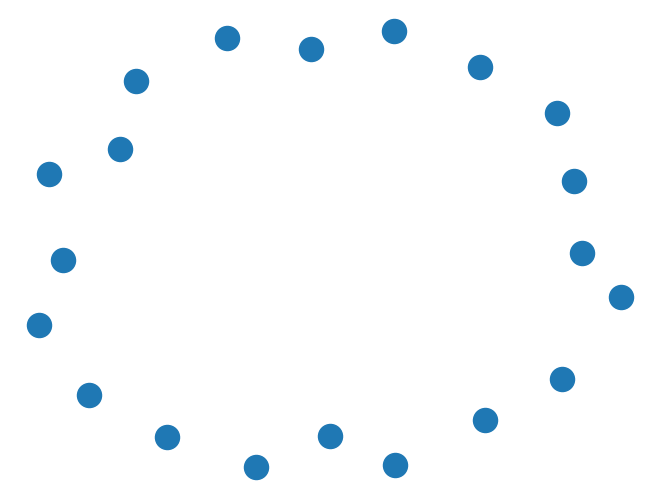

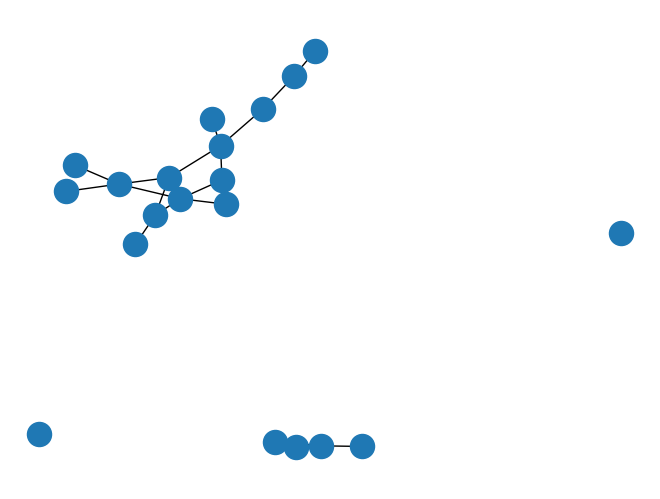

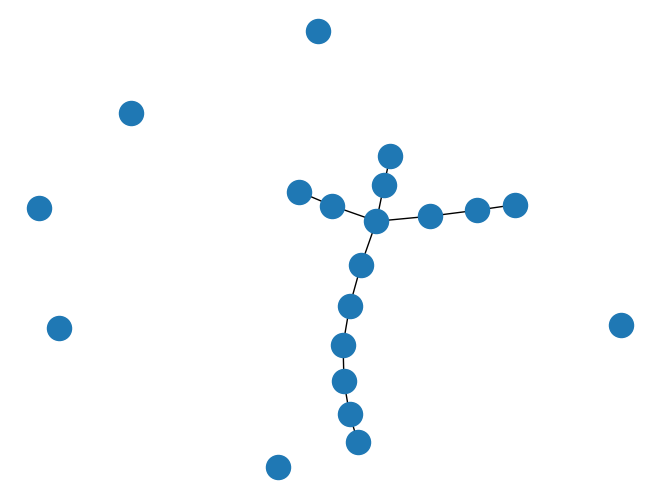

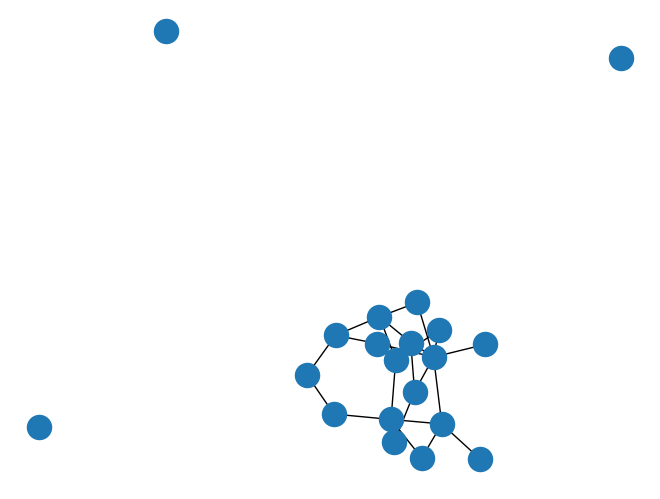

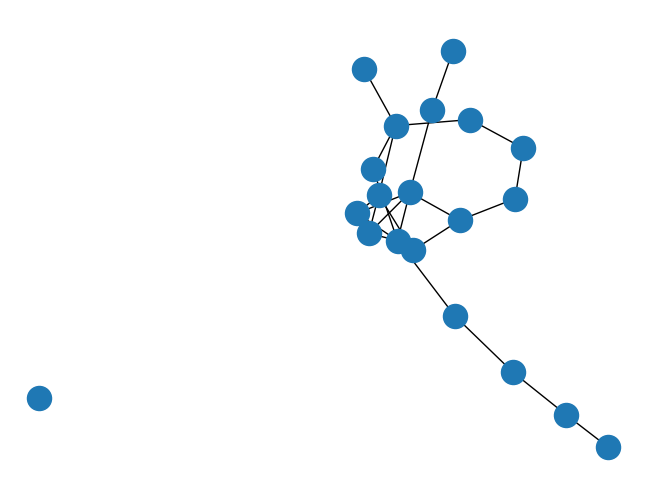

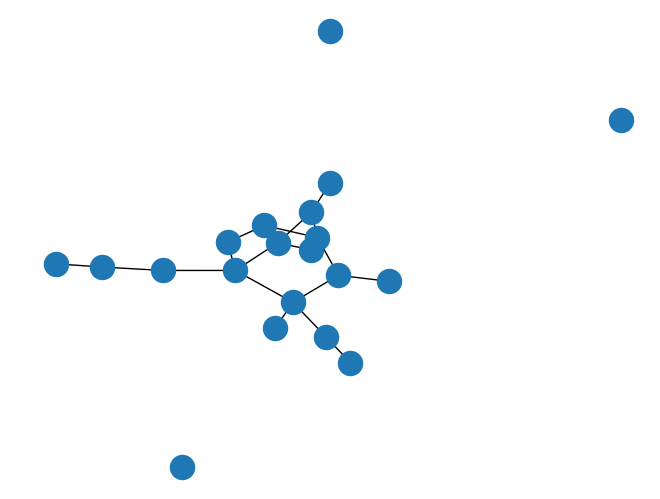

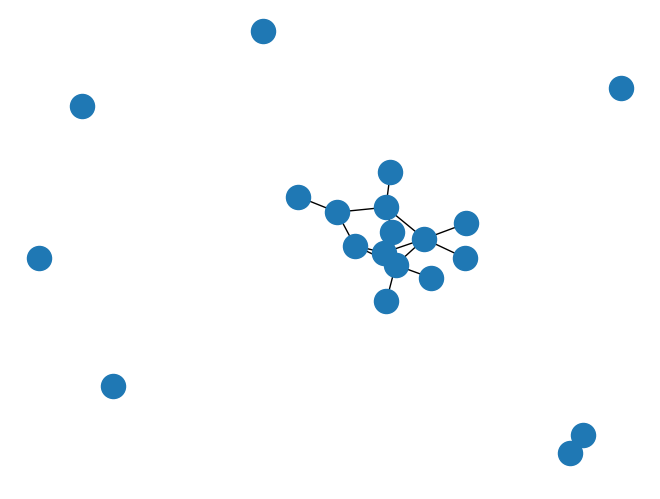

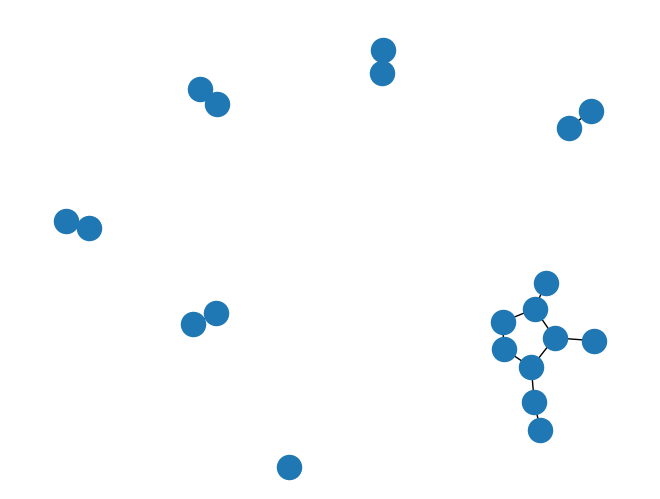

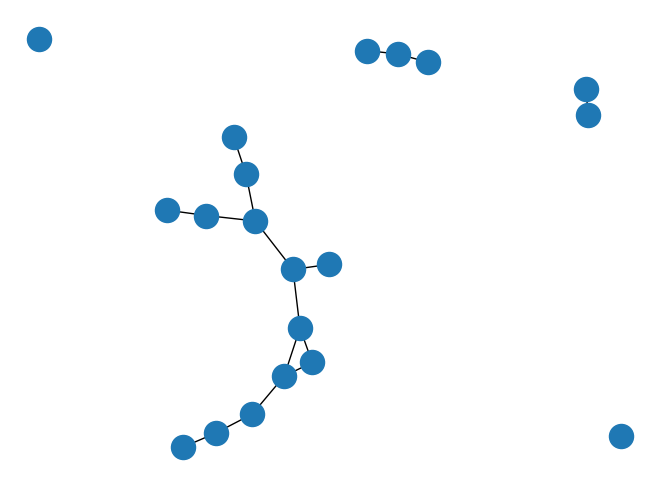

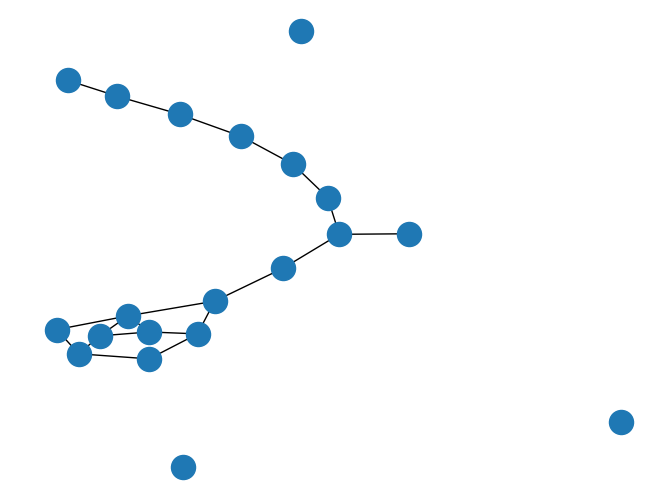

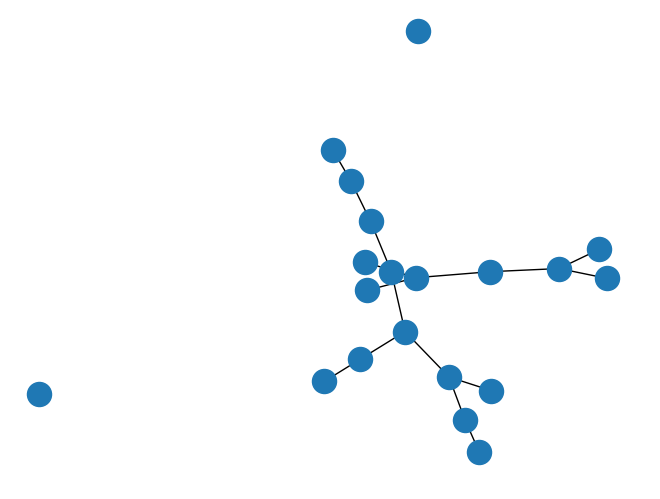

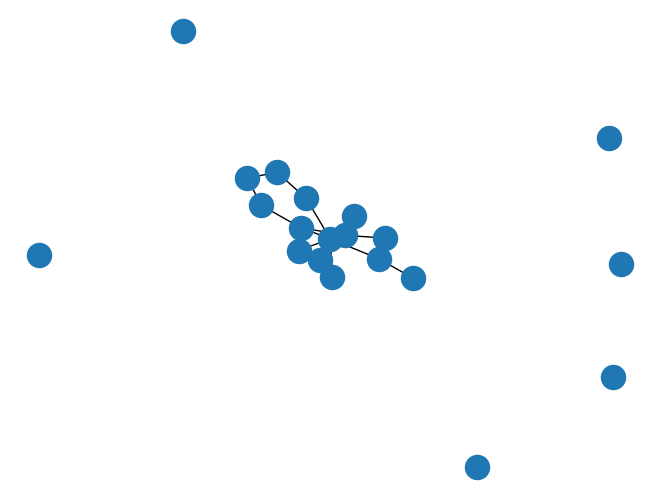

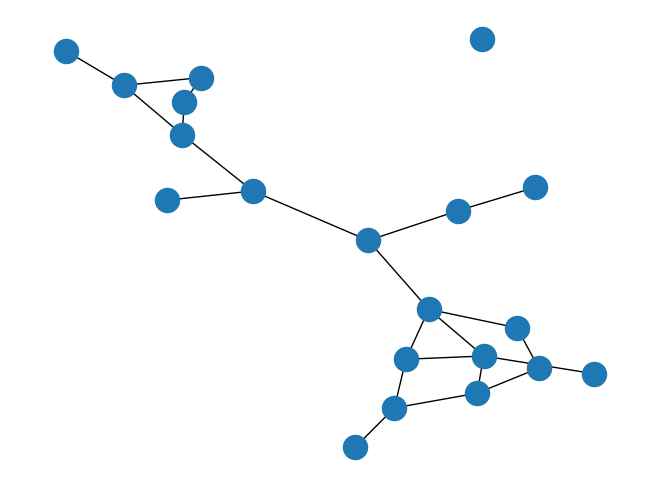

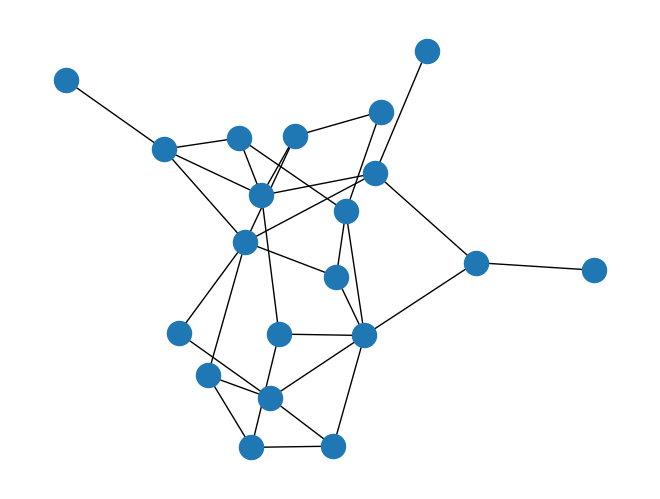

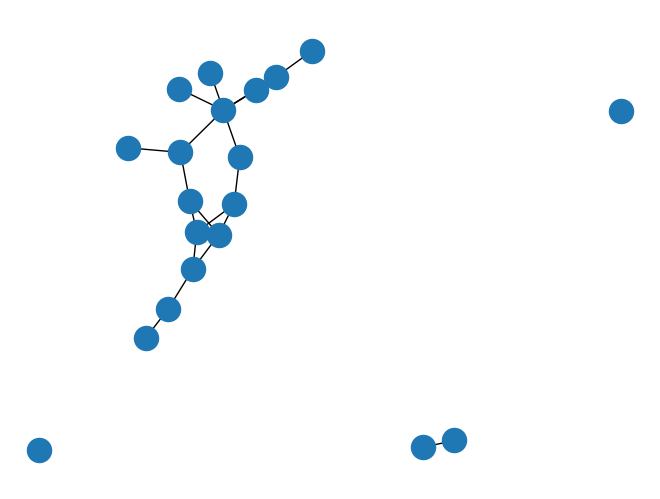

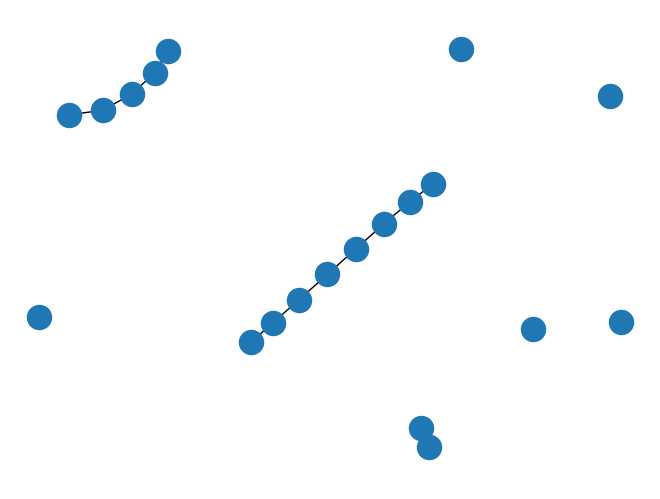

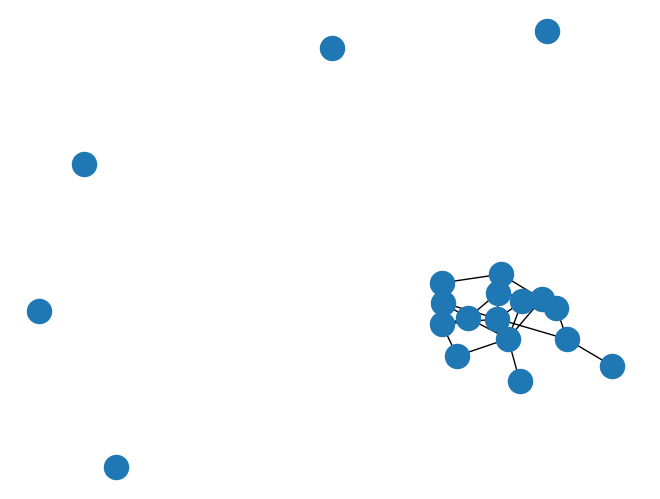

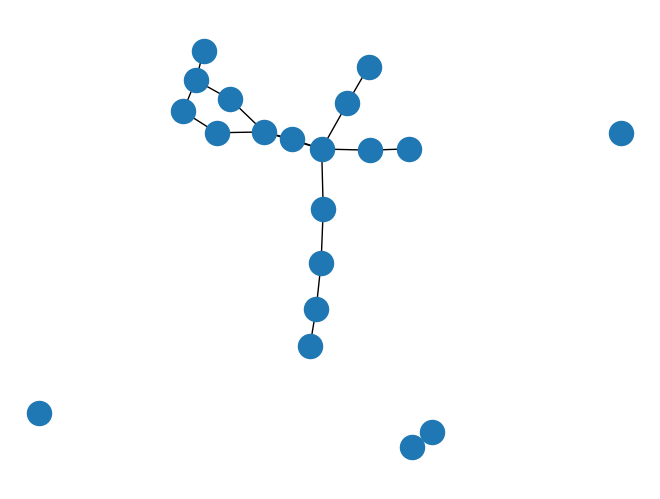

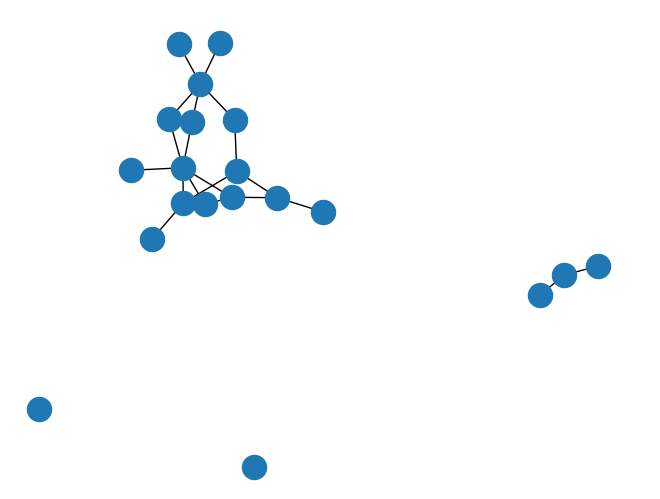

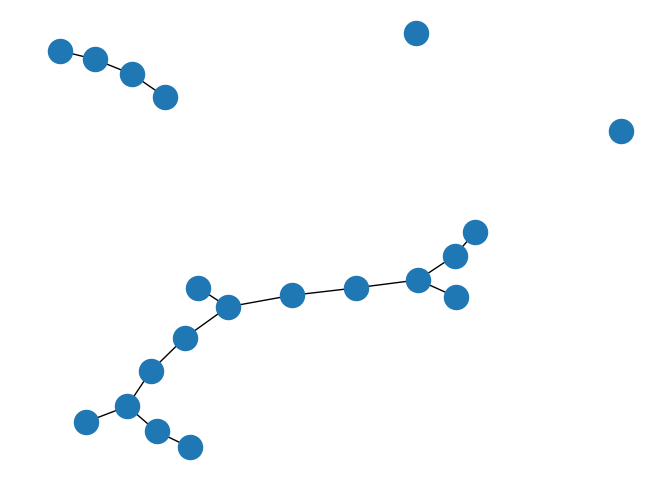

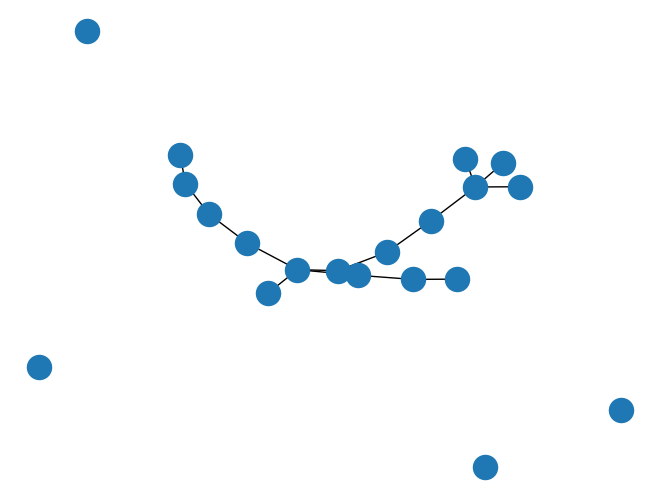

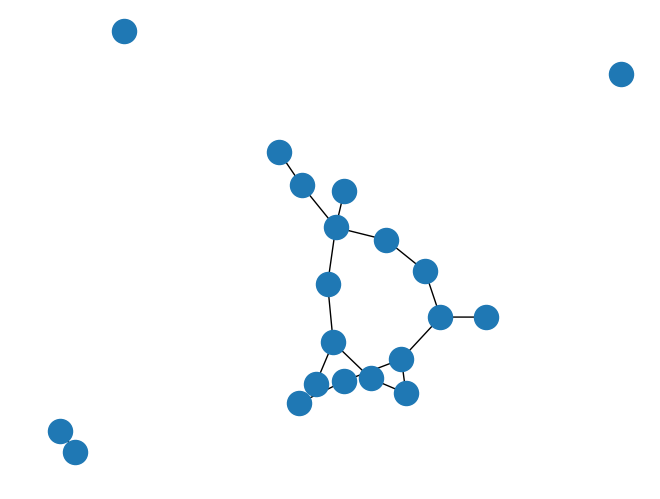

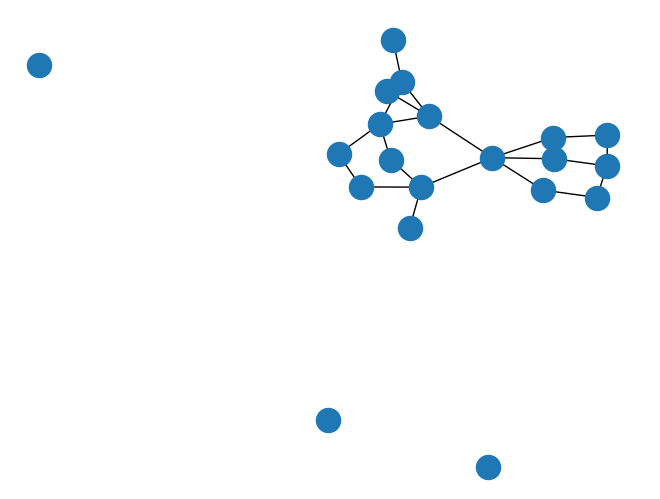

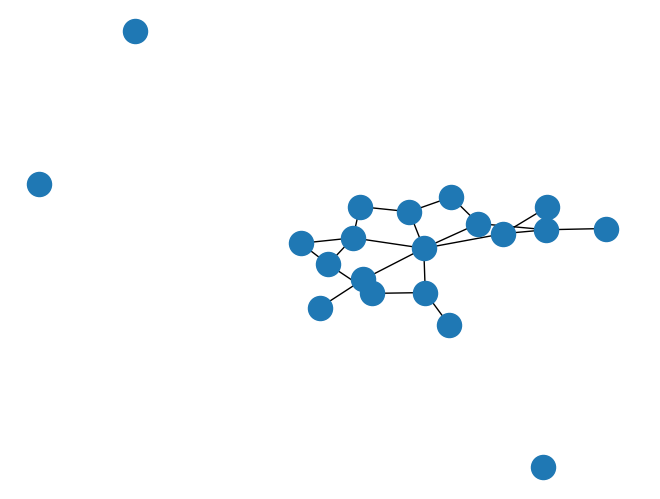

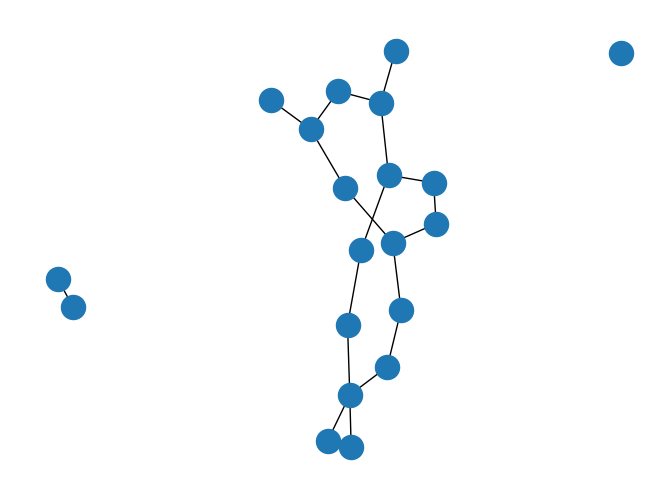

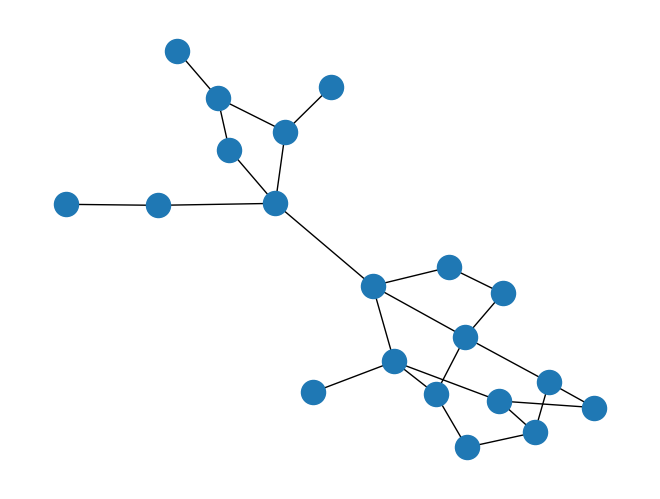

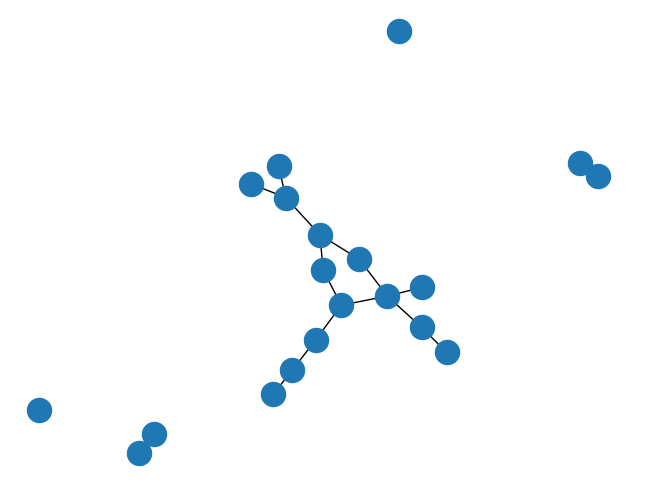

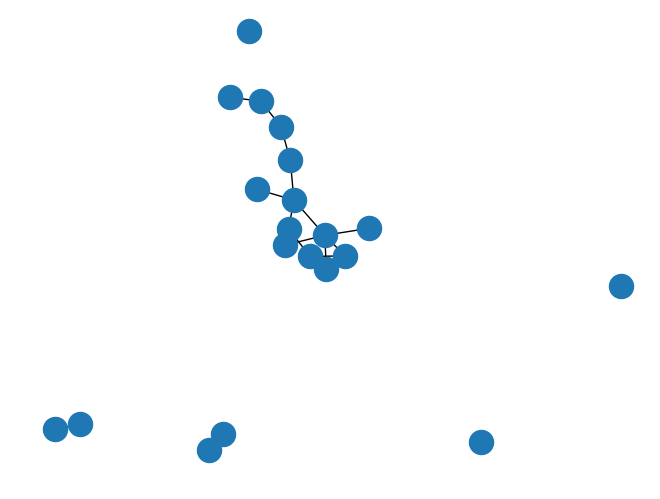

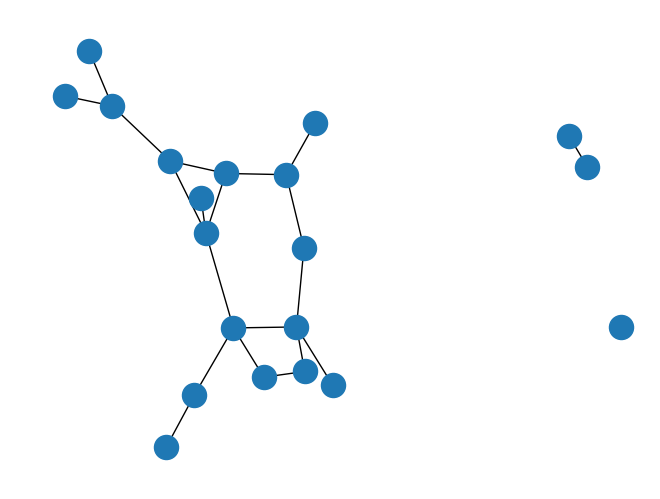

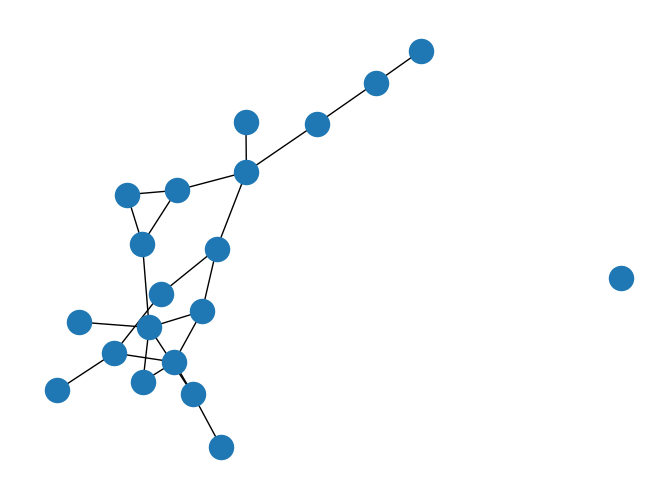

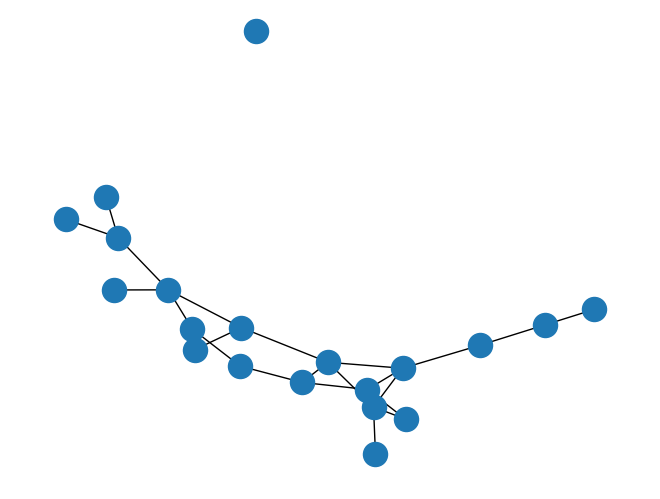

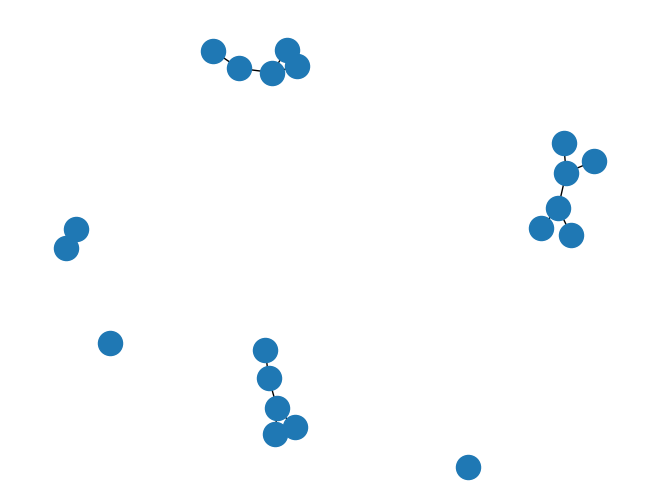

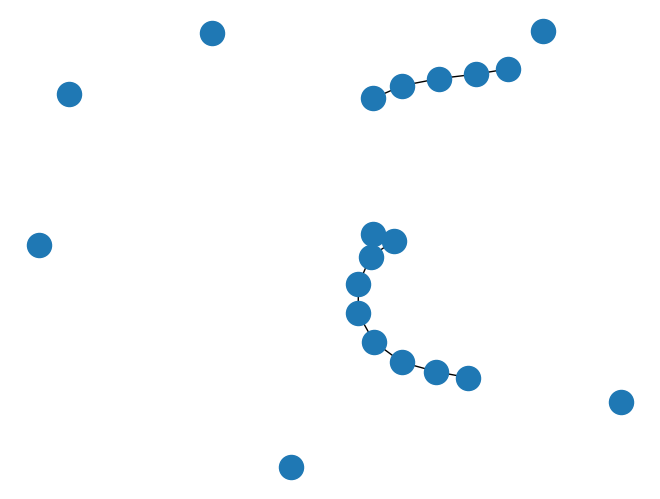

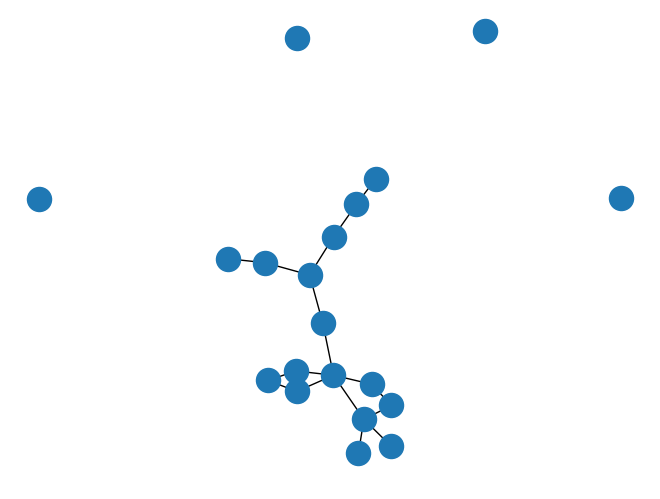

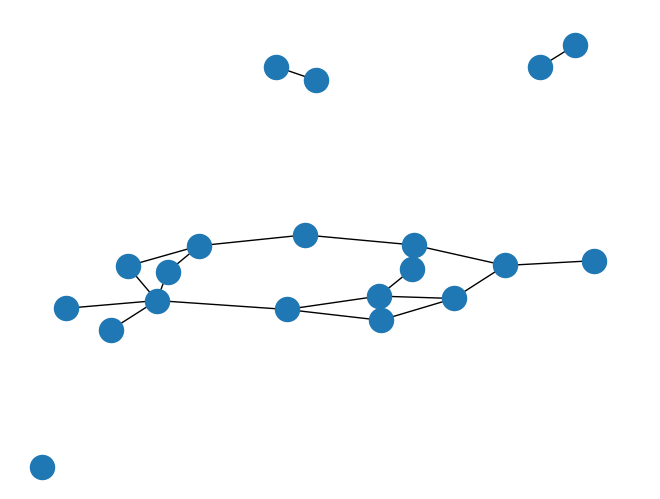

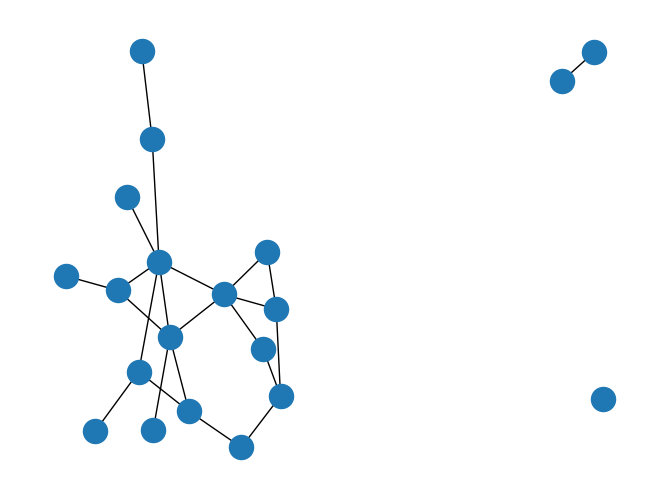

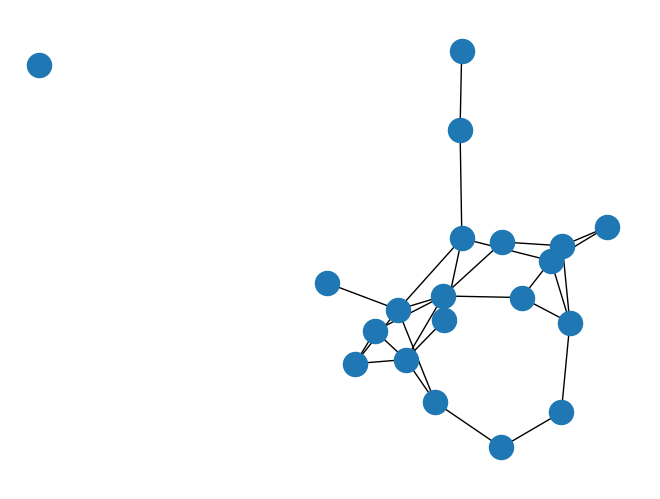

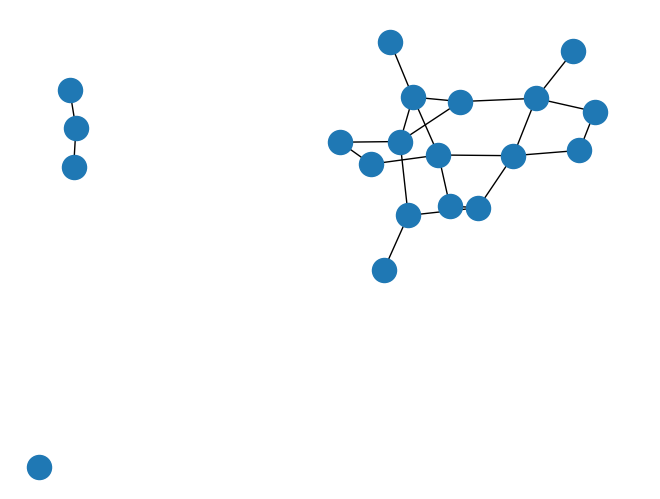

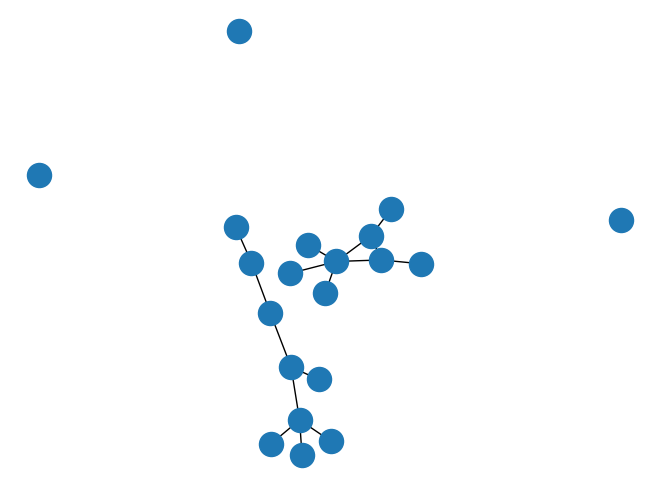

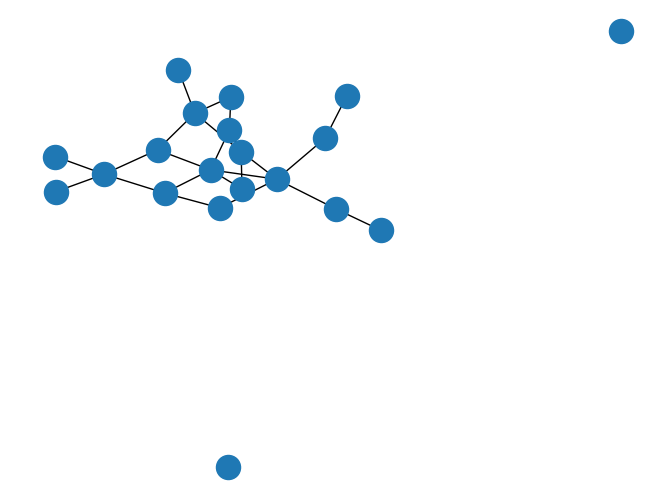

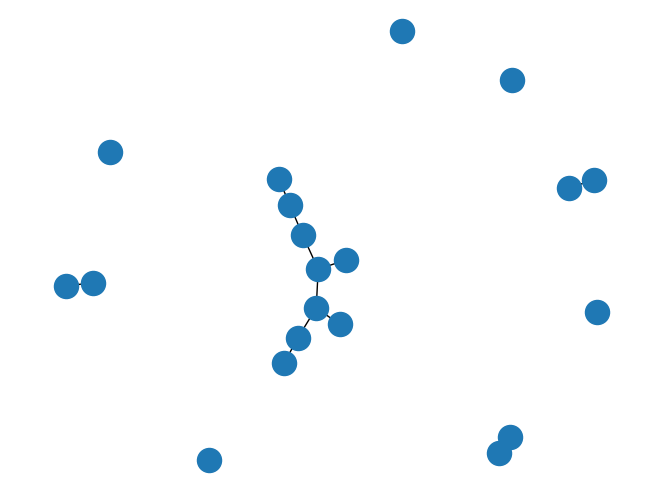

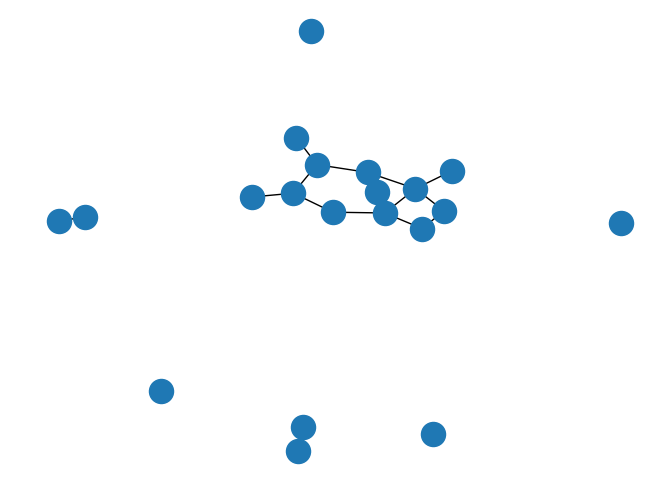

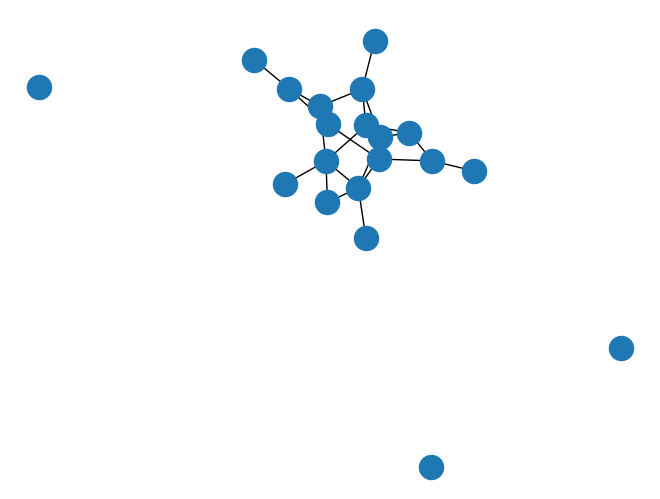

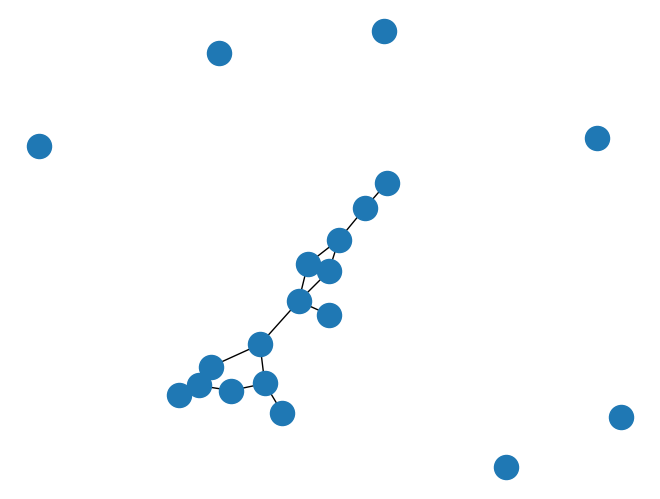

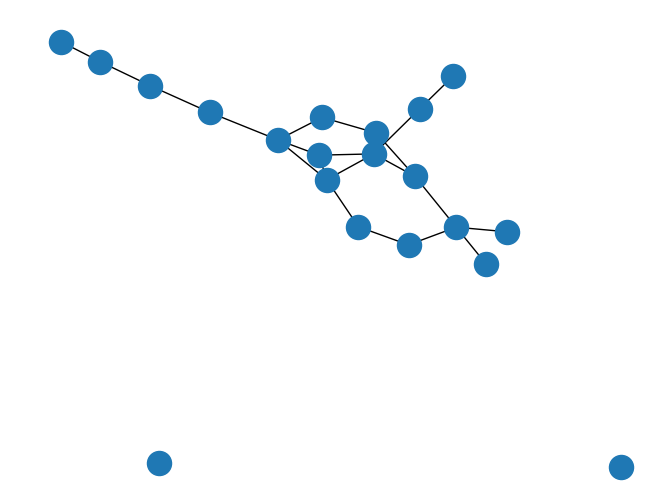

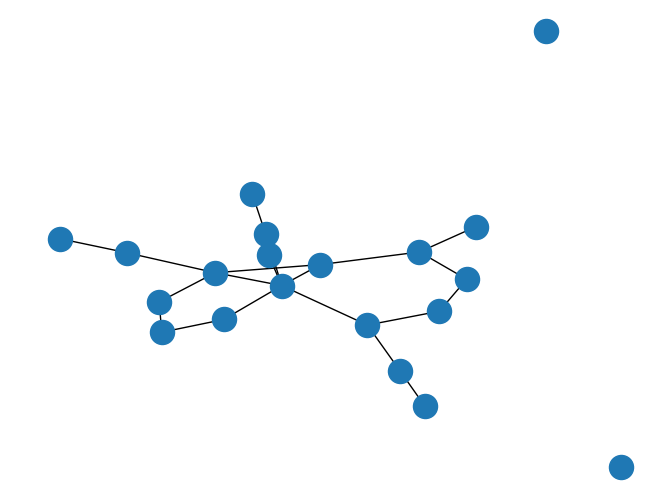

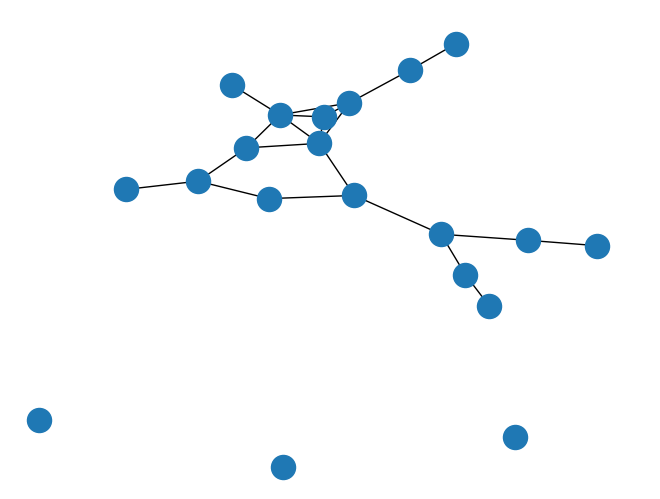

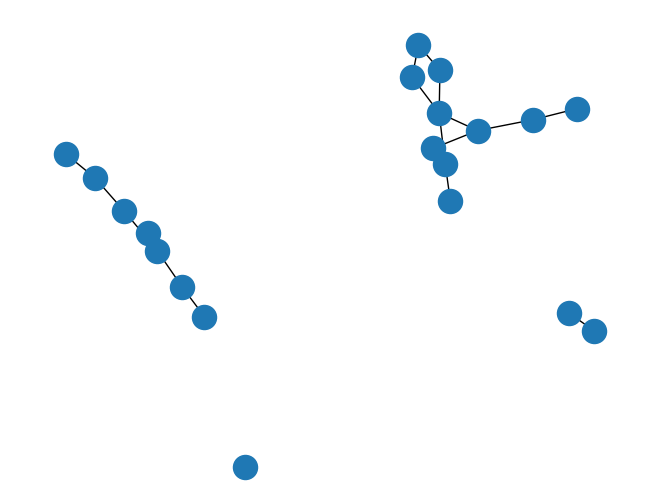

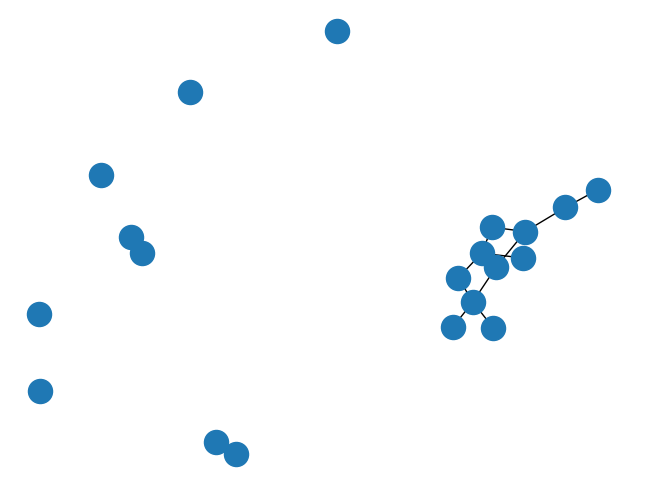

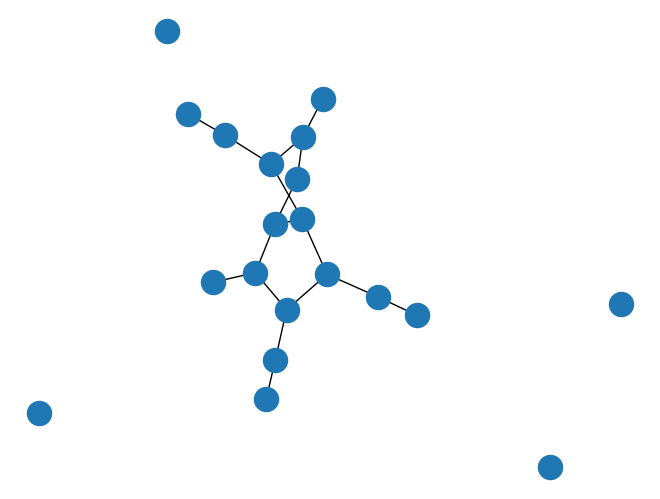

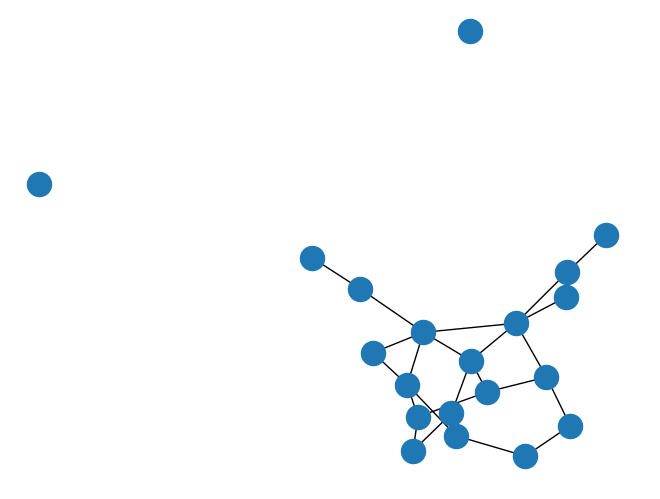

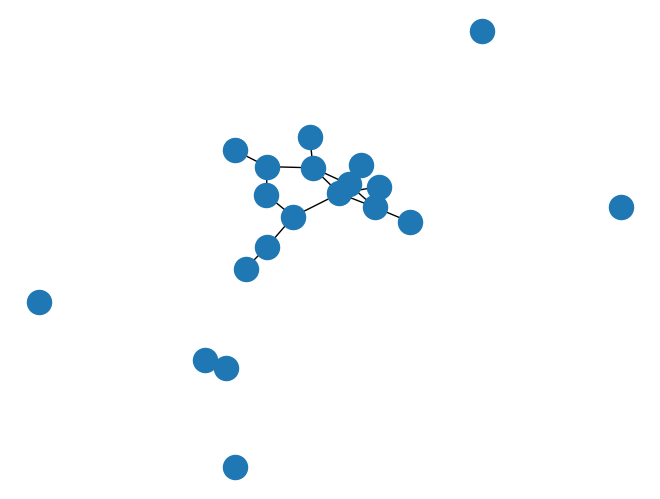

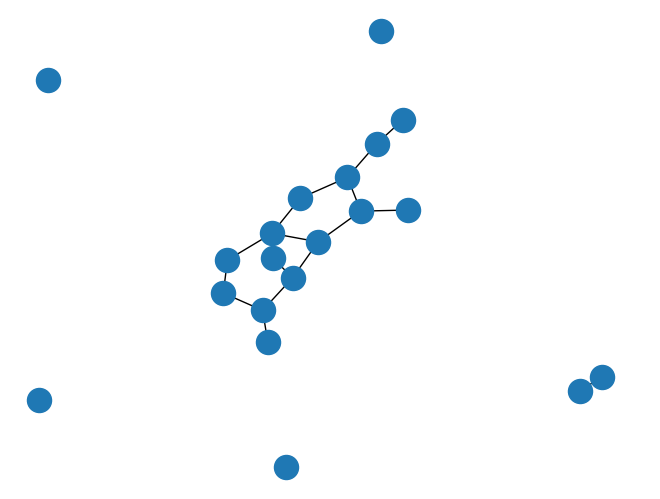

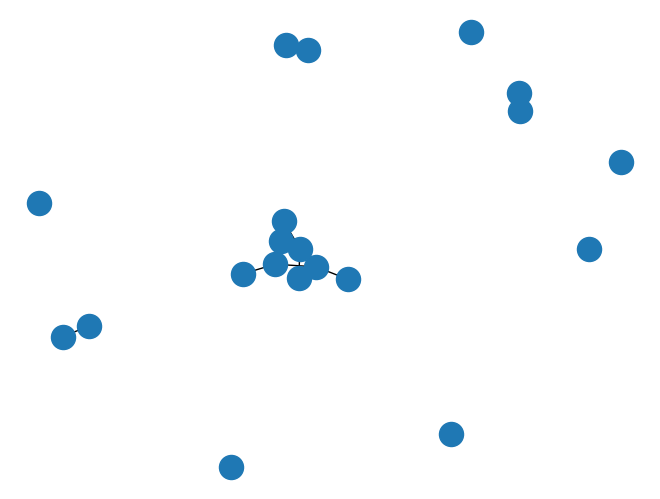

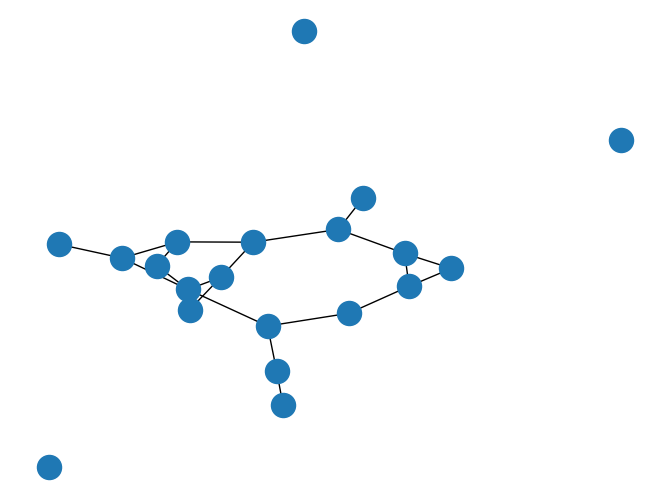

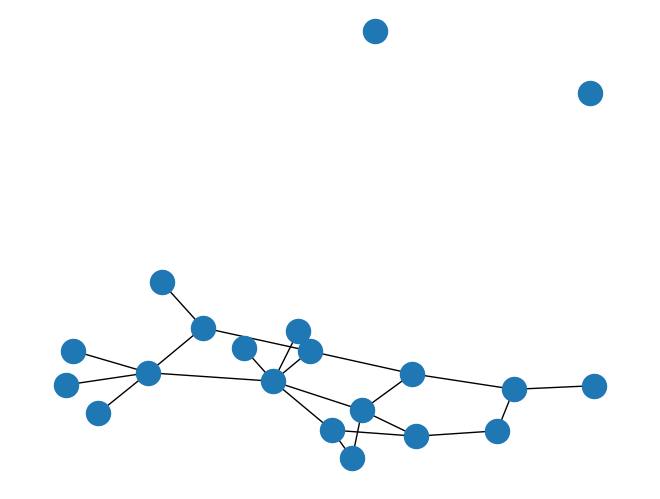

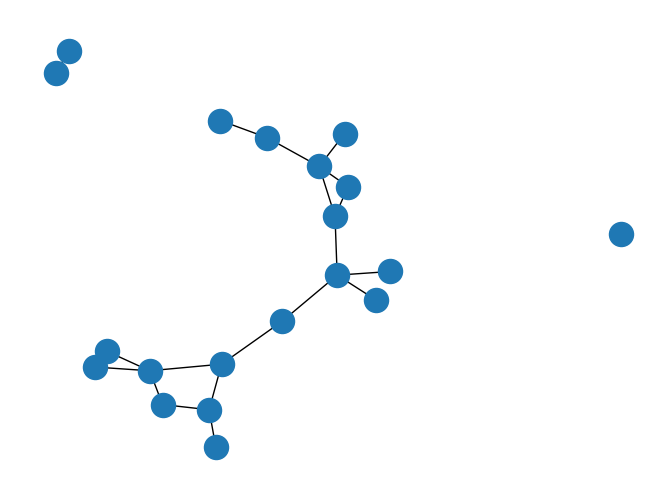

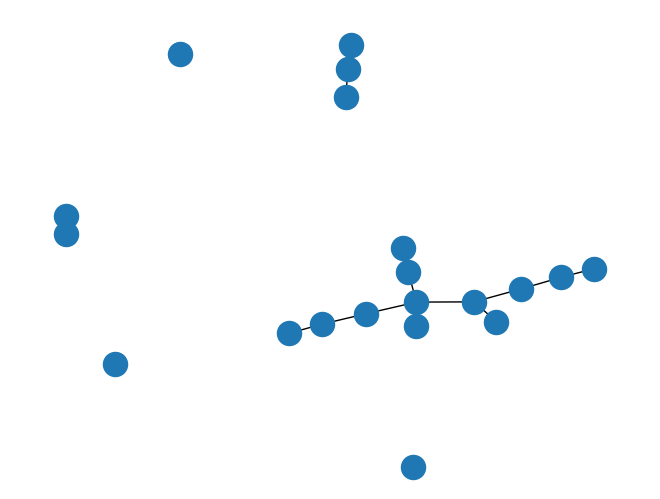

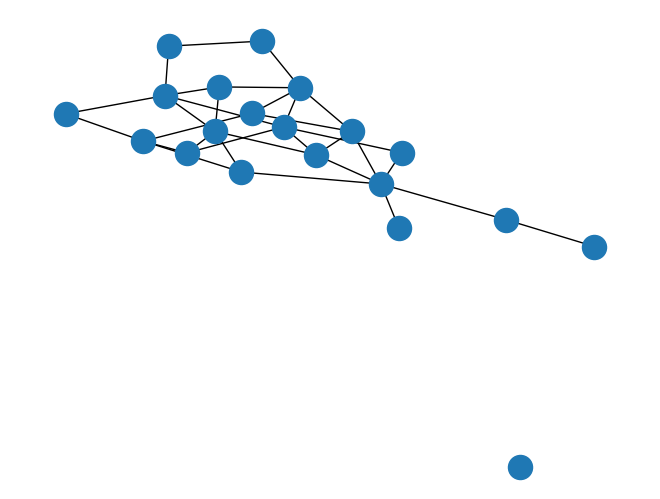

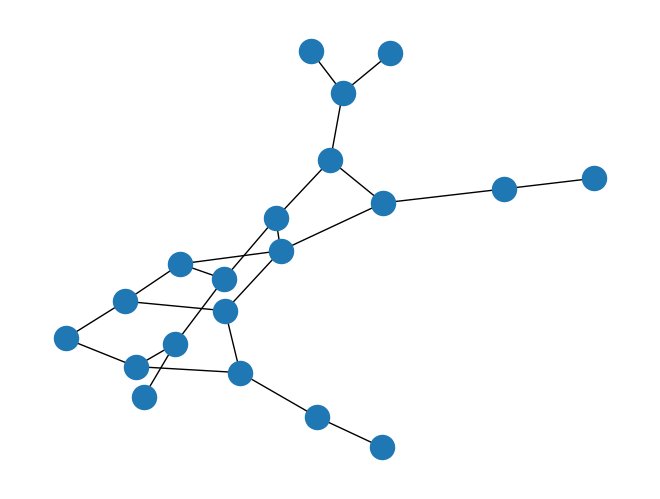

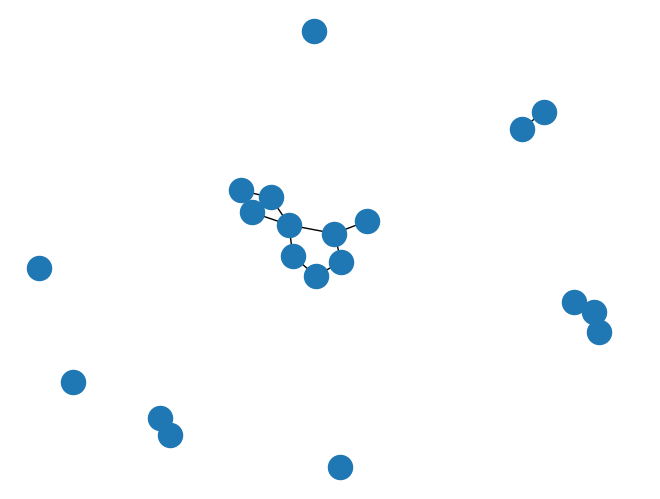

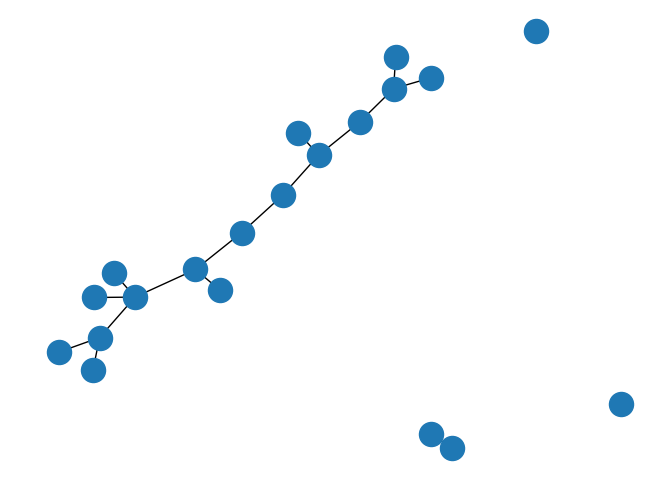

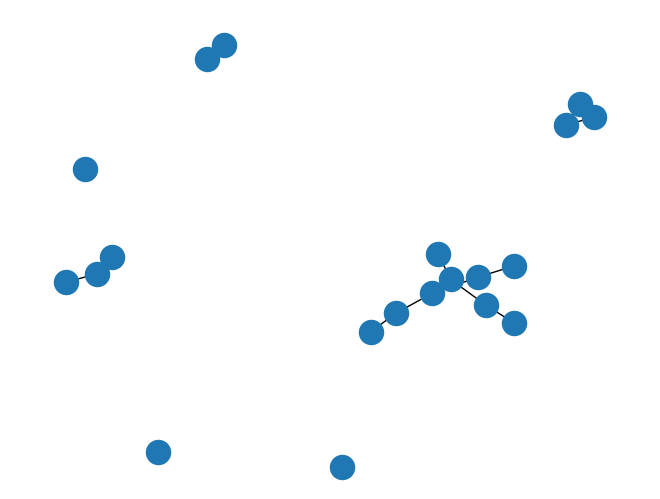

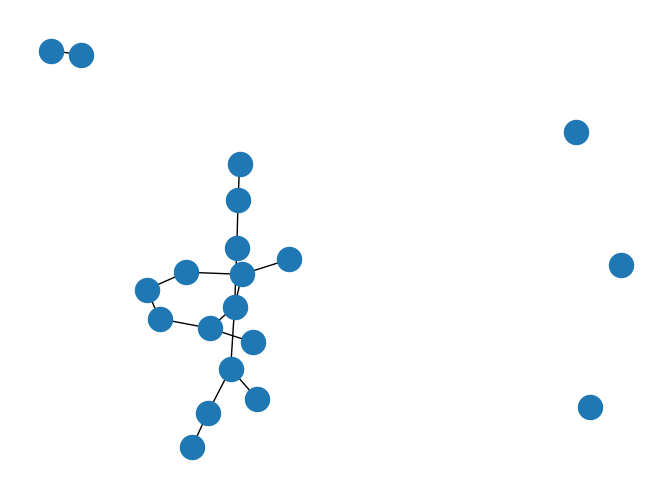

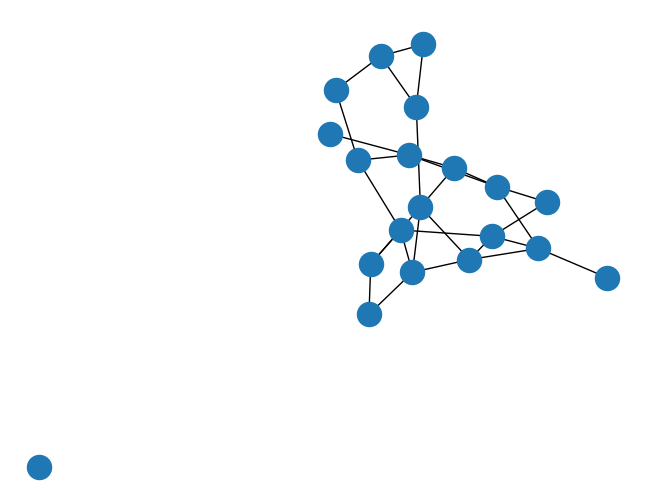

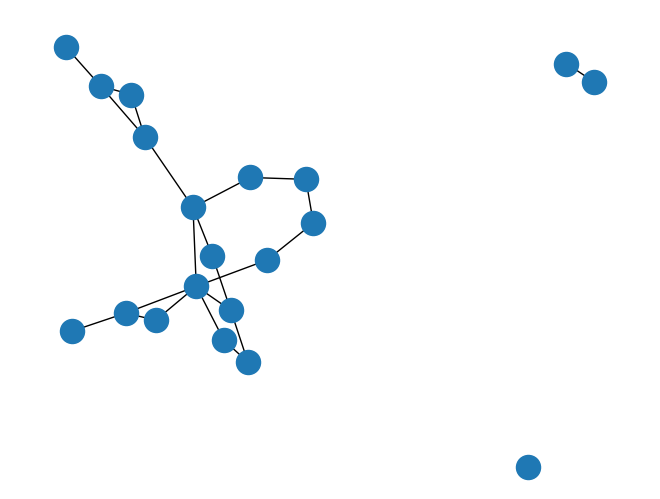

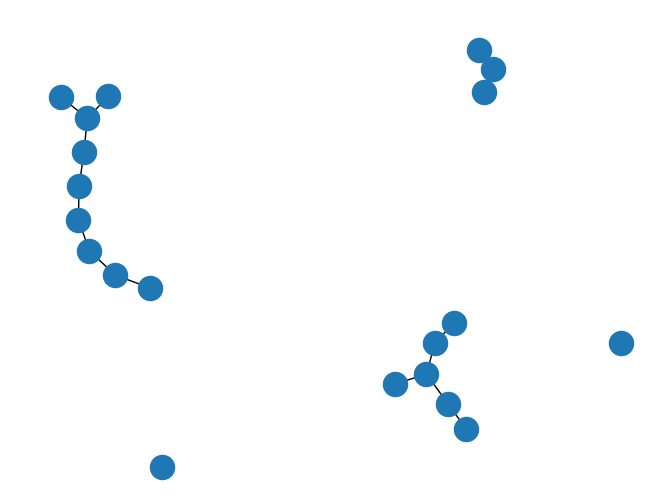

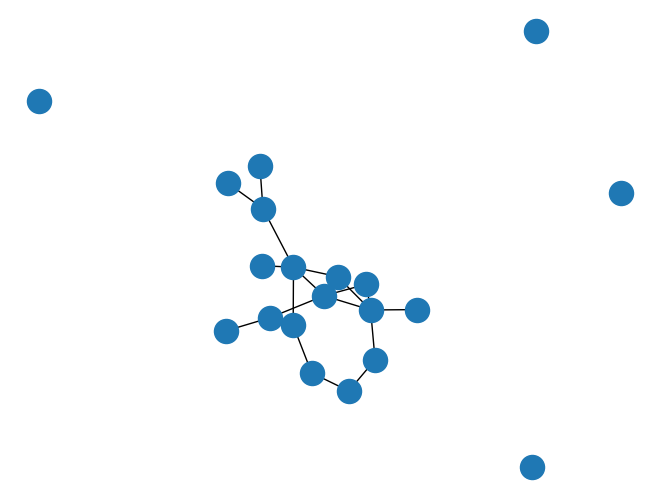

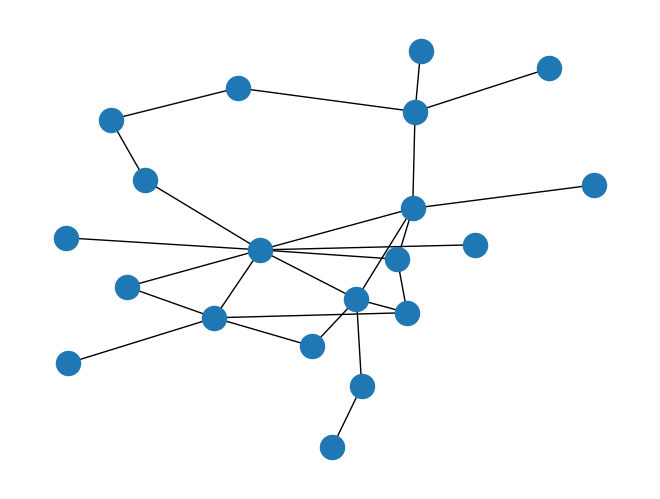

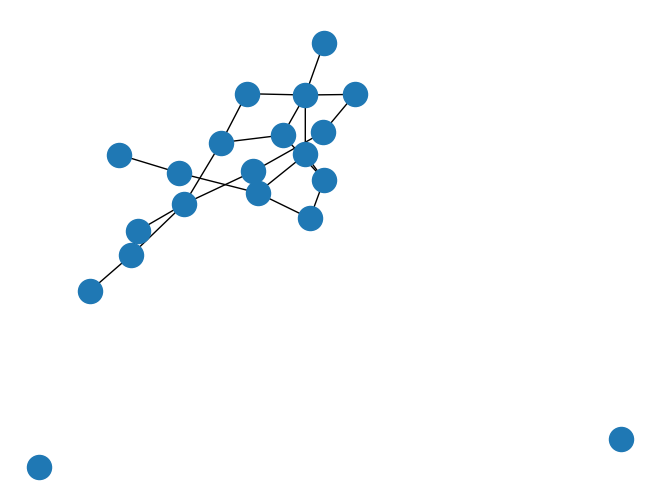

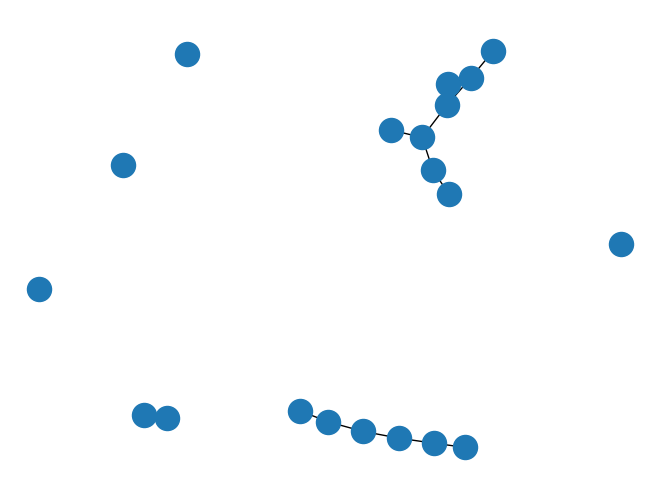

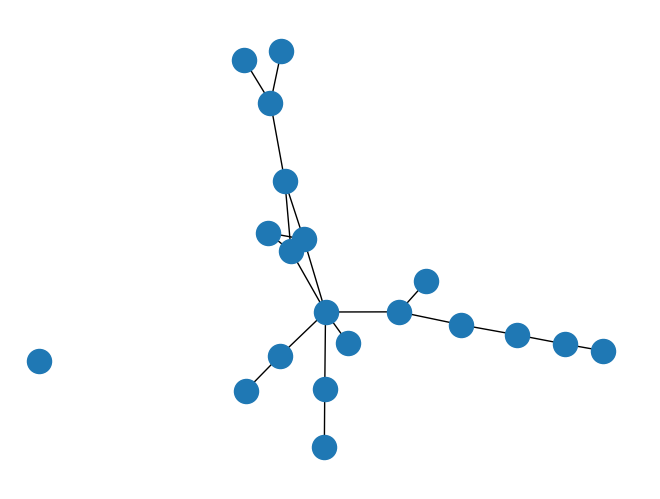

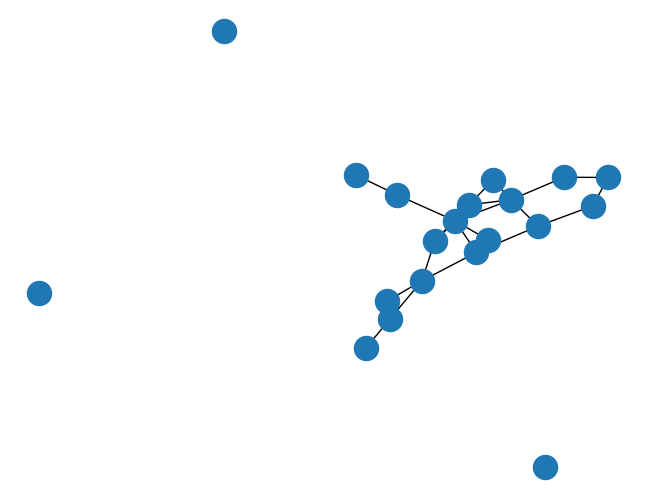

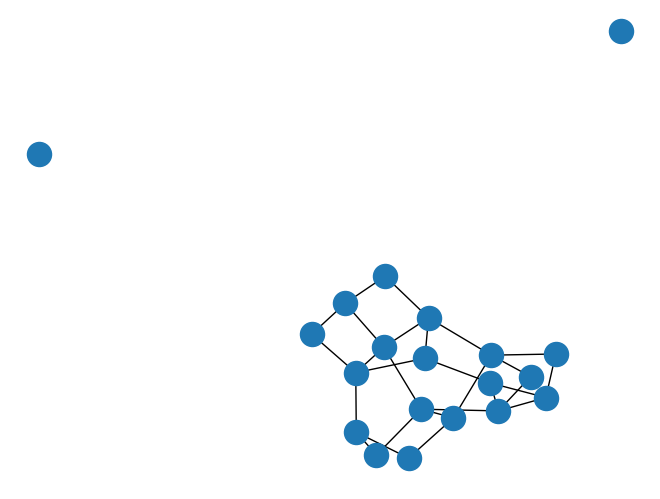

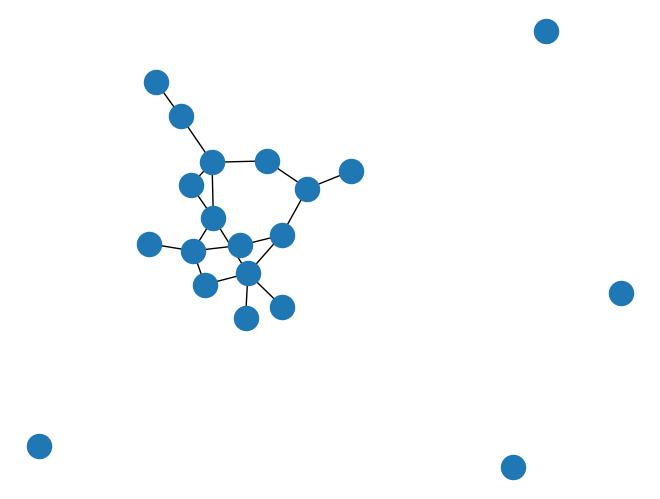

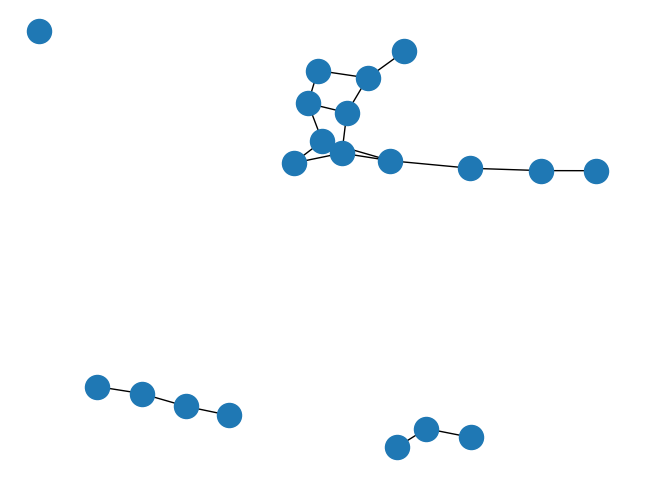

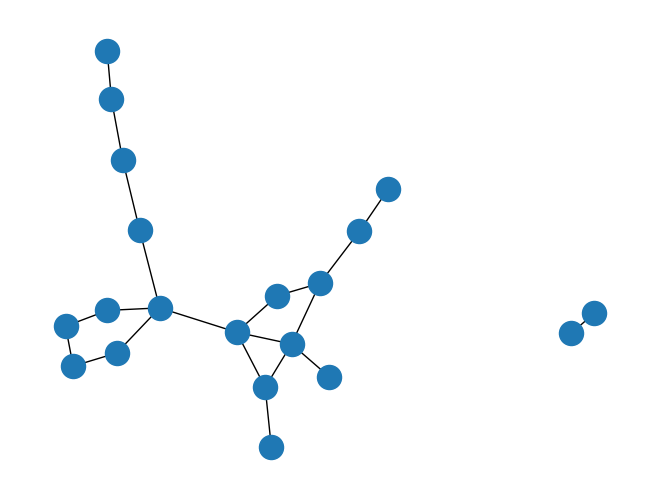

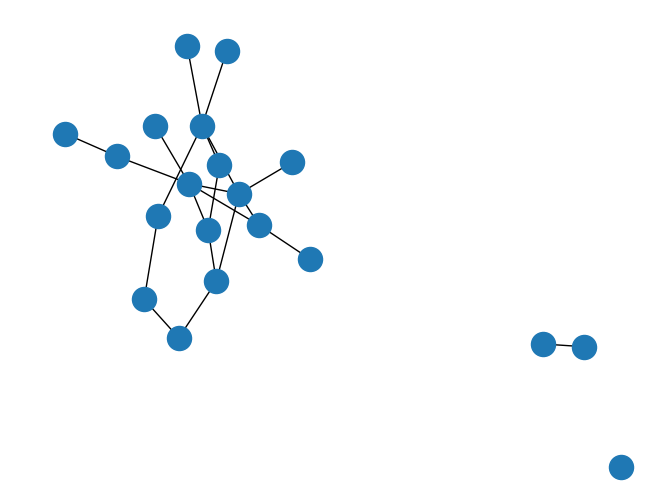

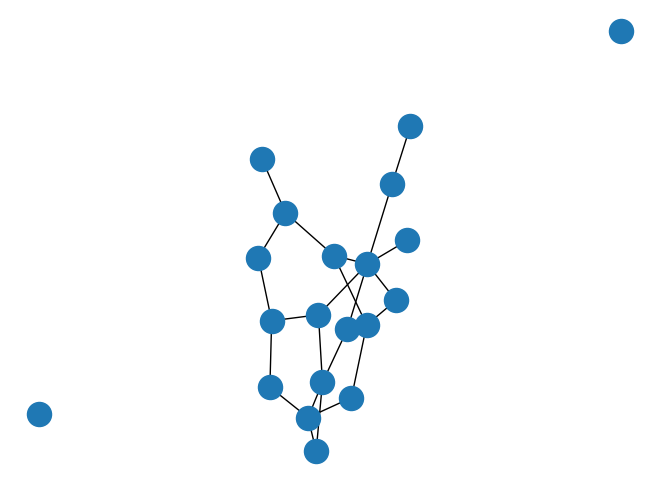

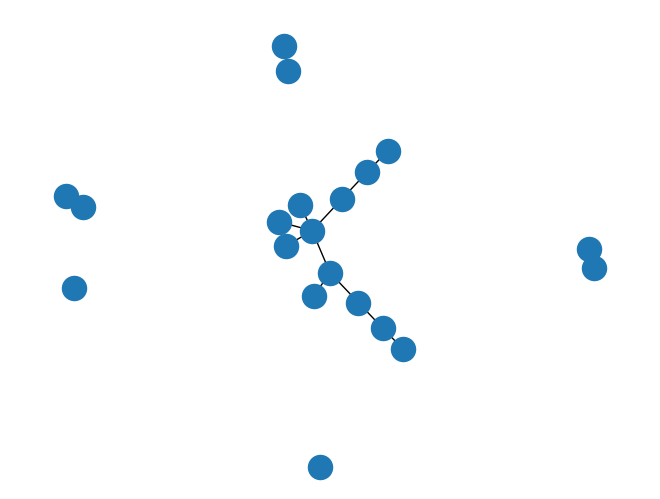

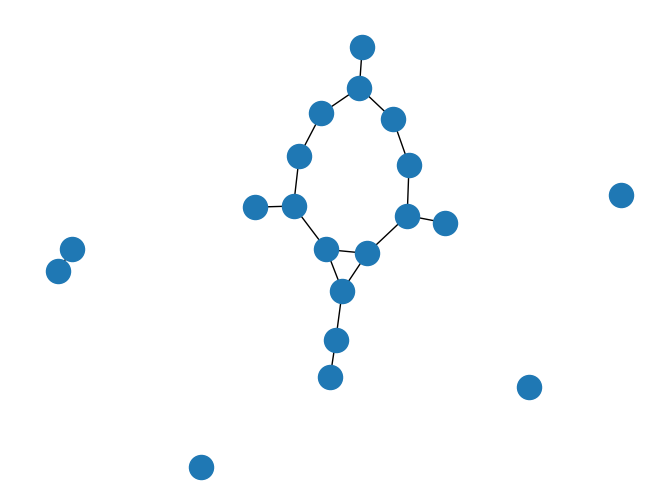

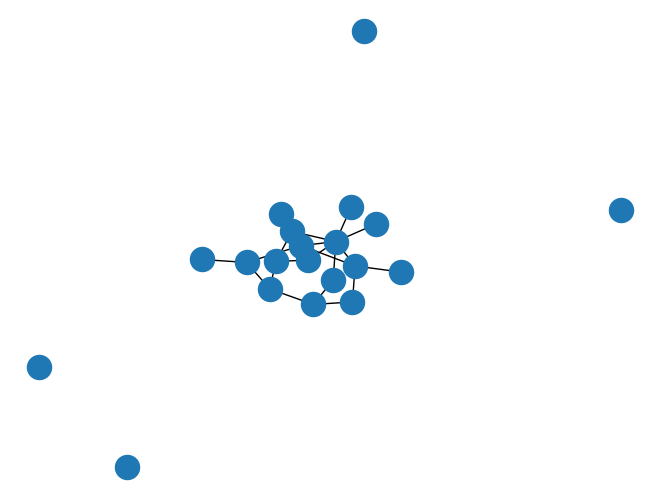

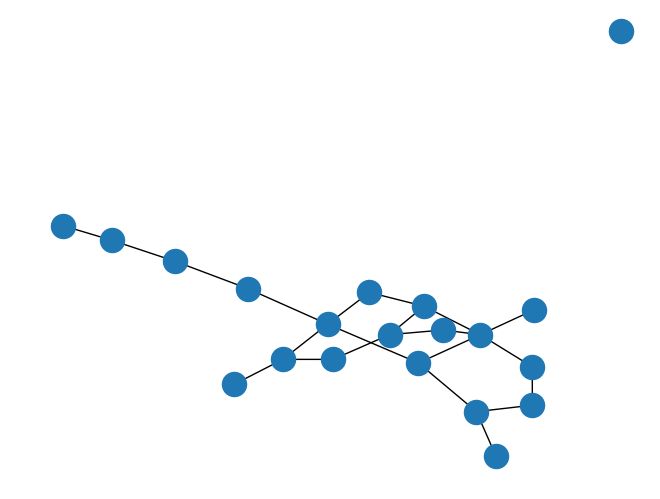

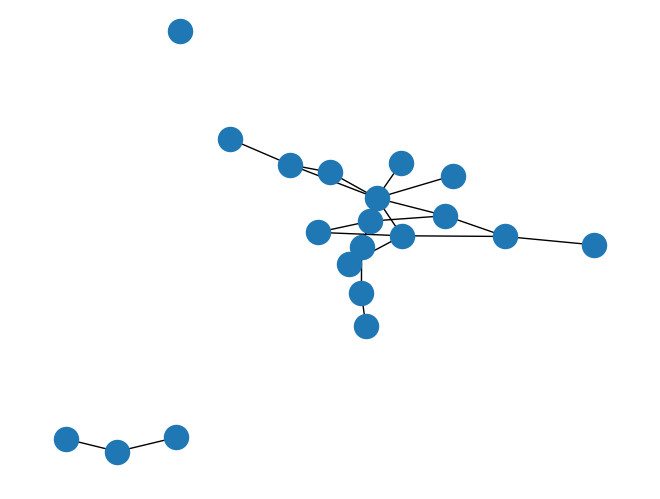

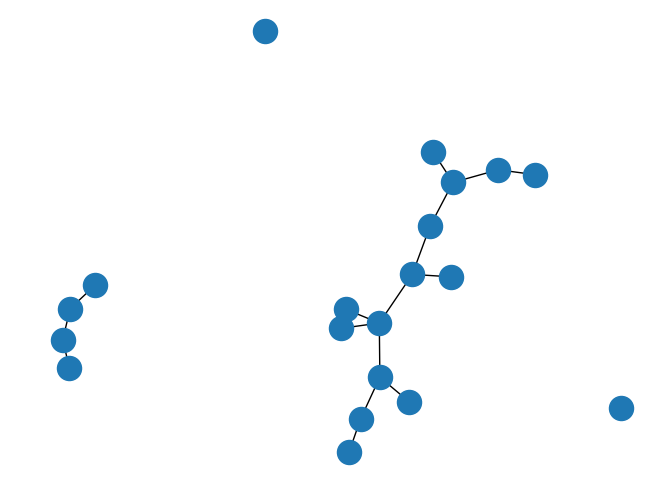

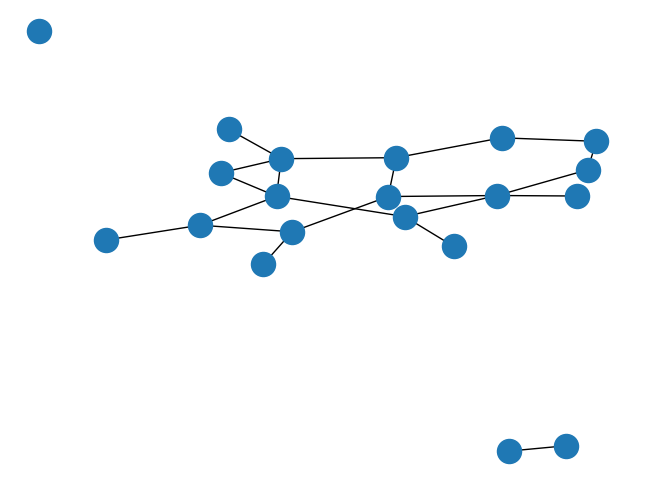

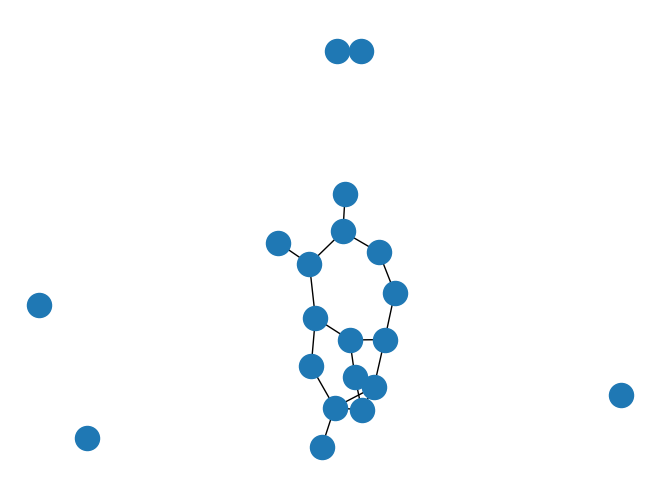

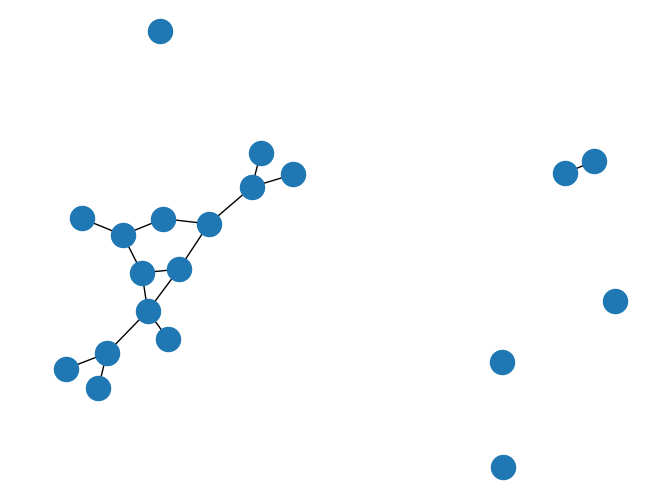

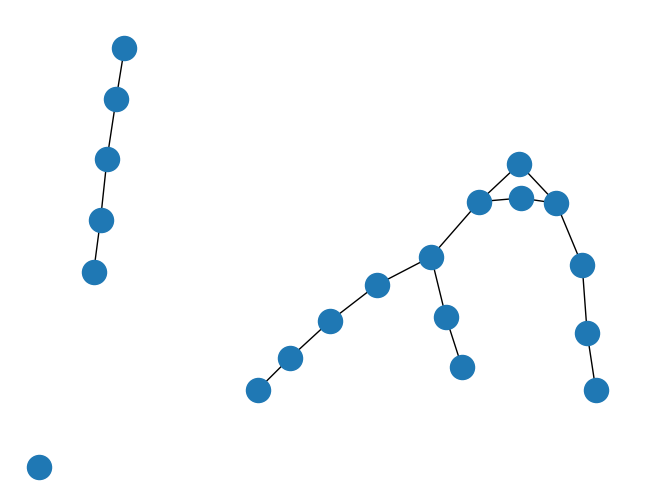

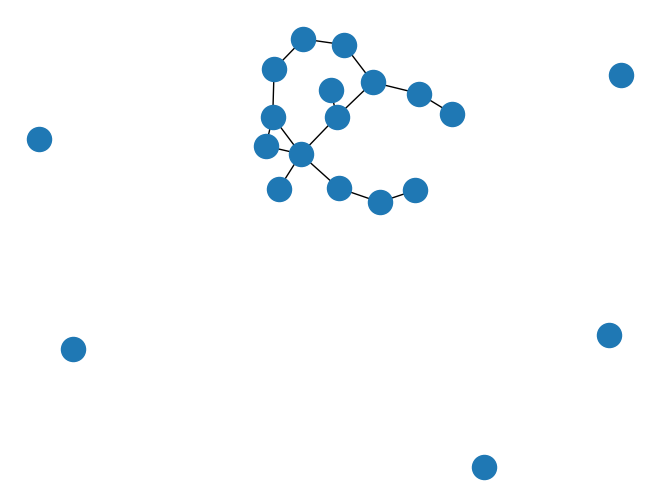

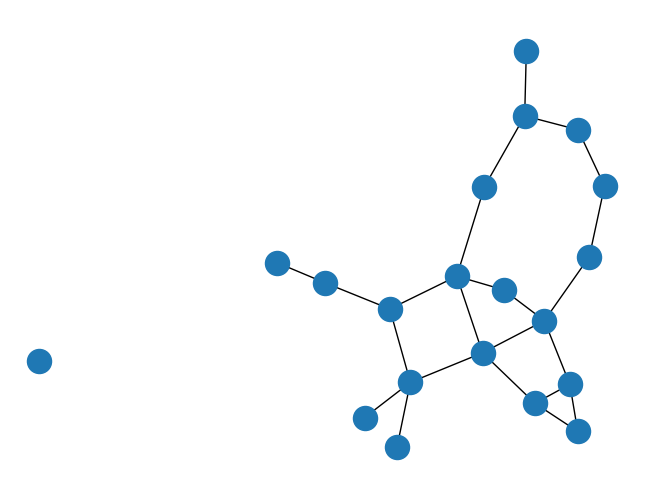

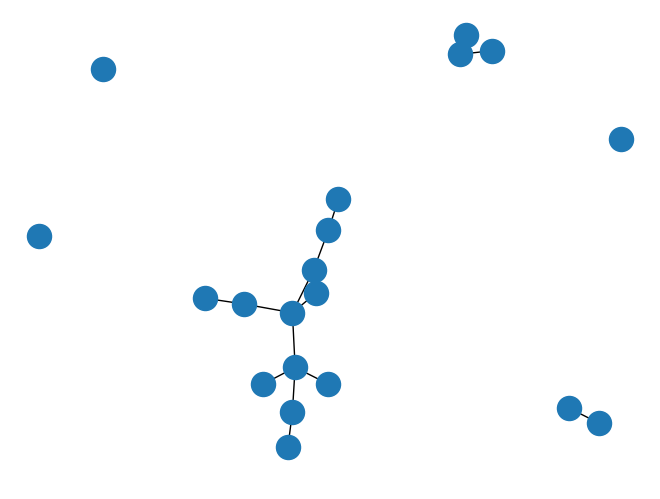

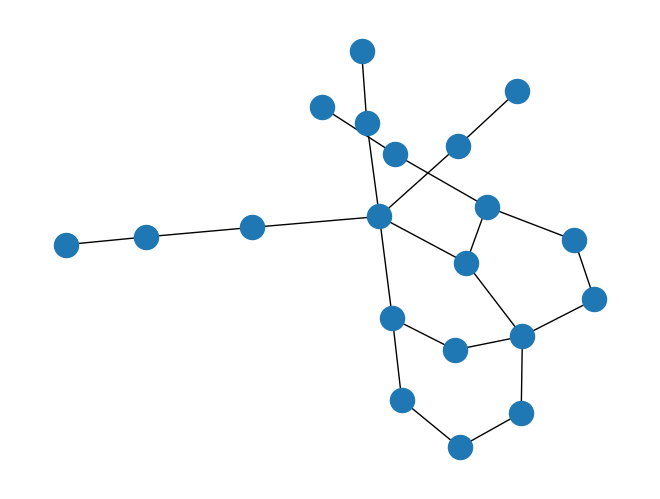

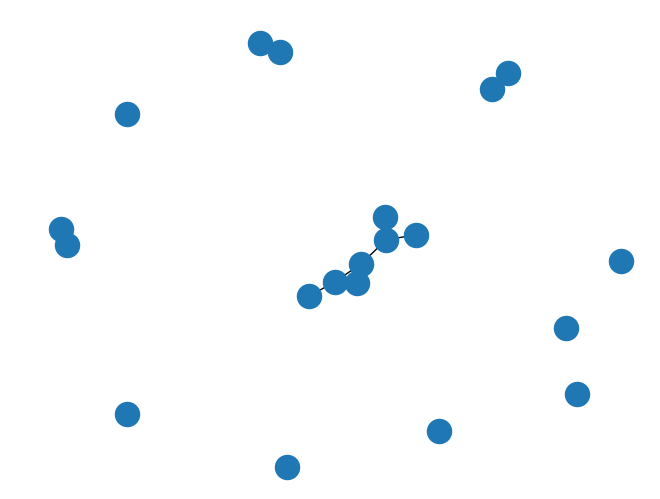

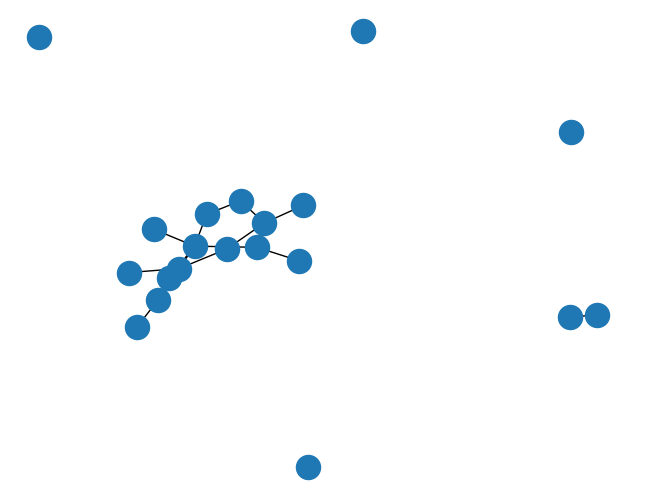

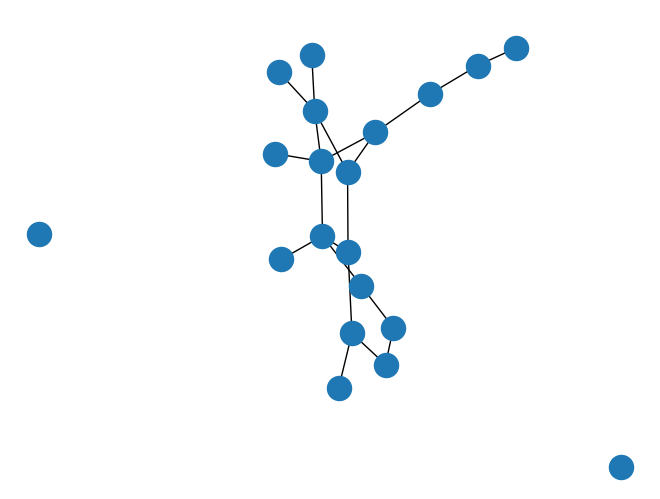

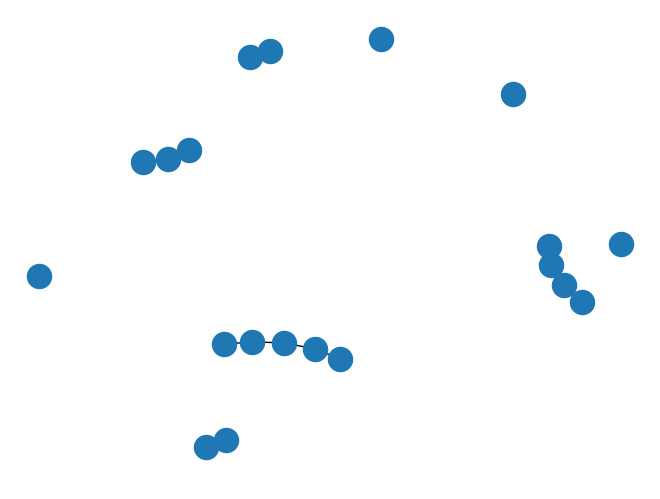

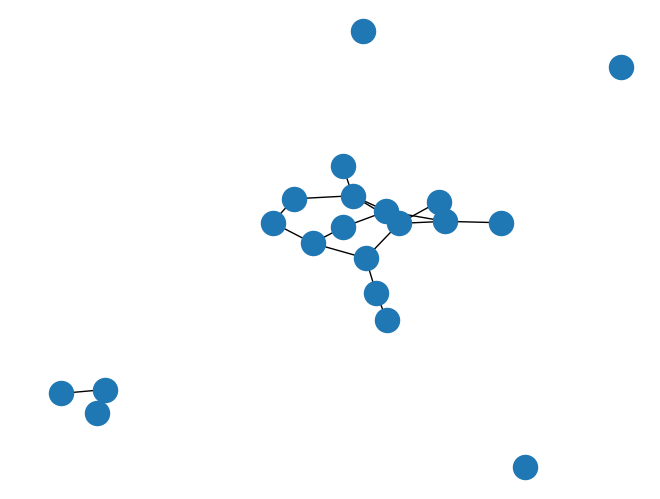

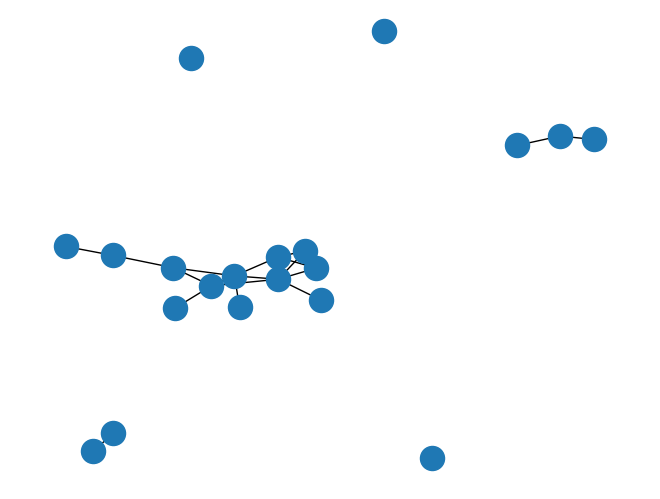

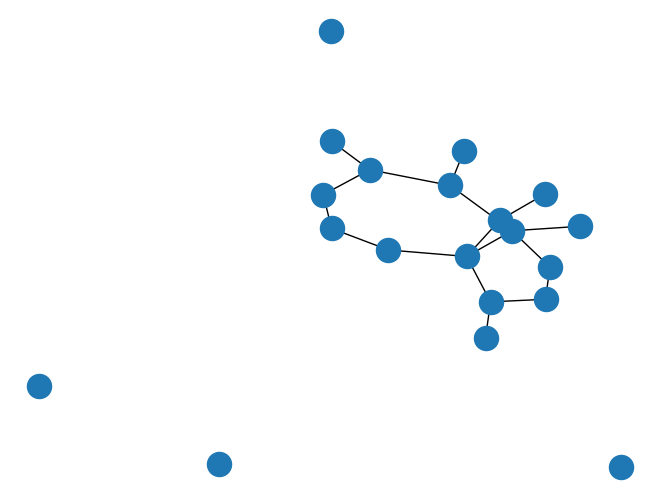

In [4]:
n = 20
its = 100000
G = nx.empty_graph(n)
m = 0
t = 0
a = 2.2
b = 0.001
for step in range(its):
    if step %1000 == 0:
        nx.draw(G)
        plt.show()
    i, j = np.random.randint(0, n, 2)
    if i == j:
        continue
    if G.has_edge(i, j):
        delta_t = -len(list(nx.common_neighbors(G, i, j)))
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = len(list(nx.common_neighbors(G, i, j)))
        delta_m = +1
        G.add_edge(i, j)

    dH = a * delta_m - b * delta_t
    if np.log(np.random.uniform()) < -dH:
        m += delta_m
        t += delta_t
    else:
        # revert
        if delta_m == 1:
            G.remove_edge(i, j)
        else:
            G.add_edge(i, j)

In [ ]:
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 100000
burn_in = 20000

up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 100)
for b in b_vals:
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))


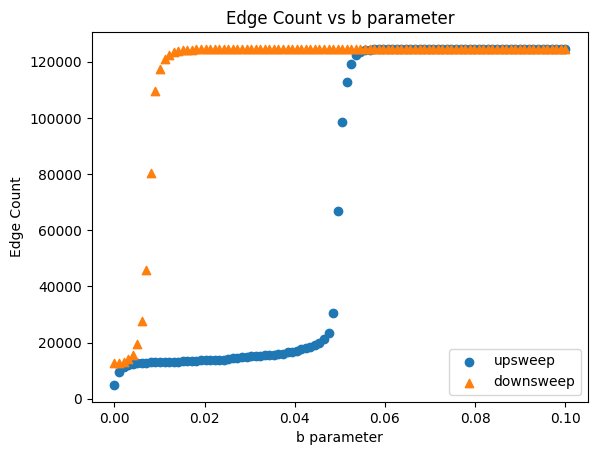

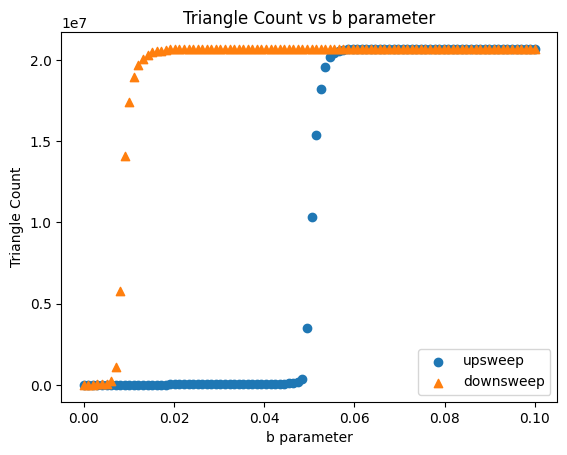

In [4]:
plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')
#title legend
plt.title('Edge Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Edge Count')
plt.legend()

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')
#title legend
plt.title('Triangle Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Triangle Count')
plt.legend()
plt.show()

In [ ]:
newGraph

complement

energy

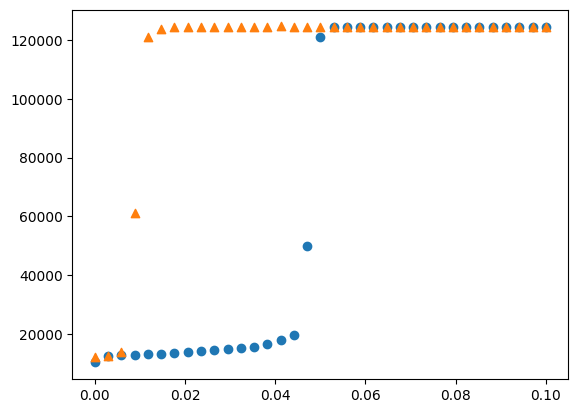

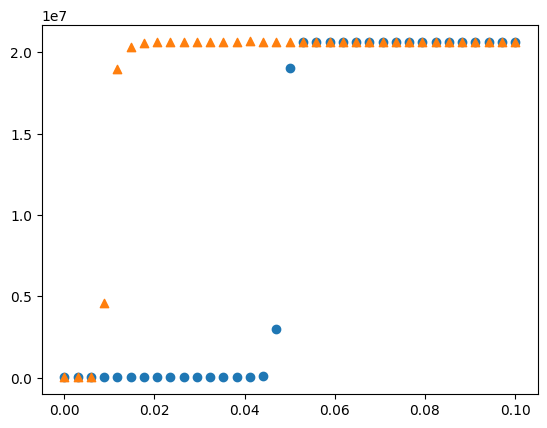

In [ ]:
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 35)
for b in b_vals:
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j))) #G.neighbors(i).intersection(G.neighbors(j))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j))) #.size?
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


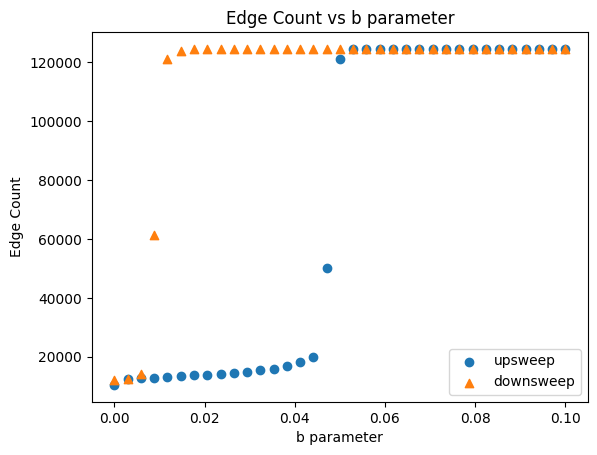

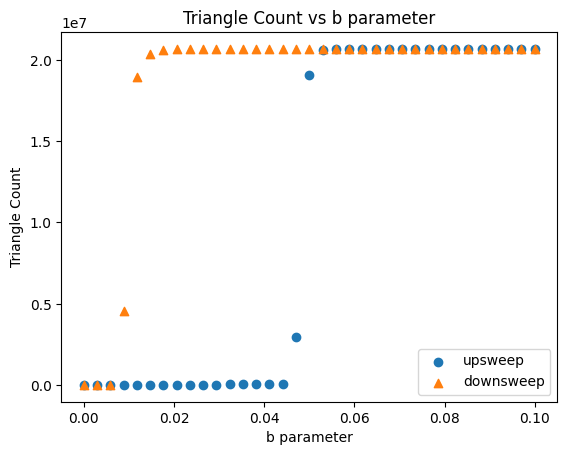

In [6]:
plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')
#title legend
plt.title('Edge Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Edge Count')
plt.legend()

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')
#title legend
plt.title('Triangle Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Triangle Count')
plt.legend()
plt.show()

In [23]:
import time
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 35)
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(nx.common_neighbors(G, i, j)) # does G._adj[i].keys() & G._adj[j].keys()
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(nx.common_neighbors(G, i, j))
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(nx.common_neighbors(G, i, j))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(nx.common_neighbors(G, i, j))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


b = 0.0000, time = 5.84 s
b = 0.0029, time = 9.10 s
b = 0.0059, time = 9.22 s
b = 0.0088, time = 9.33 s
b = 0.0118, time = 6.40 s
b = 0.0147, time = 13.06 s
b = 0.0176, time = 10.77 s
b = 0.0206, time = 10.84 s
b = 0.0235, time = 11.74 s
b = 0.0265, time = 10.82 s
b = 0.0294, time = 10.26 s
b = 0.0324, time = 11.25 s
b = 0.0353, time = 8.75 s
b = 0.0382, time = 11.18 s
b = 0.0412, time = 12.60 s
b = 0.0441, time = 12.79 s
b = 0.0471, time = 22.68 s
b = 0.0500, time = 62.29 s
b = 0.0529, time = 68.14 s
b = 0.0559, time = 67.01 s
b = 0.0588, time = 68.34 s
b = 0.0618, time = 66.88 s
b = 0.0647, time = 65.18 s
b = 0.0676, time = 62.77 s
b = 0.0706, time = 66.14 s
b = 0.0735, time = 64.40 s
b = 0.0765, time = 64.00 s
b = 0.0794, time = 65.52 s
b = 0.0824, time = 644.08 s
b = 0.0853, time = 62.81 s
b = 0.0882, time = 73.29 s


KeyboardInterrupt: 

In [2]:
class graphWithComplement:

    def __init__(self, n):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        self.graph = nx.empty_graph(n)
        self.complement = nx.complete_graph(n)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)
    
    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)
    
    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

b = 0.0000, time = 13.78 s
b = 0.0010, time = 17.26 s
b = 0.0020, time = 15.88 s
b = 0.0030, time = 15.35 s
b = 0.0040, time = 15.28 s
b = 0.0051, time = 16.80 s
b = 0.0061, time = 15.55 s
b = 0.0071, time = 12.54 s
b = 0.0081, time = 16.33 s
b = 0.0091, time = 14.83 s
b = 0.0101, time = 15.39 s
b = 0.0111, time = 13.73 s
b = 0.0121, time = 15.78 s
b = 0.0131, time = 15.45 s
b = 0.0141, time = 15.51 s
b = 0.0152, time = 14.75 s
b = 0.0162, time = 15.17 s
b = 0.0172, time = 15.57 s
b = 0.0182, time = 16.04 s
b = 0.0192, time = 16.43 s
b = 0.0202, time = 16.17 s
b = 0.0212, time = 16.57 s
b = 0.0222, time = 13.73 s
b = 0.0232, time = 15.13 s
b = 0.0242, time = 15.90 s
b = 0.0253, time = 14.85 s
b = 0.0263, time = 14.25 s
b = 0.0273, time = 16.38 s
b = 0.0283, time = 15.88 s
b = 0.0293, time = 15.58 s
b = 0.0303, time = 15.64 s
b = 0.0313, time = 17.12 s
b = 0.0323, time = 15.76 s
b = 0.0333, time = 16.79 s
b = 0.0343, time = 16.33 s
b = 0.0354, time = 16.30 s
b = 0.0364, time = 16.26 s
b

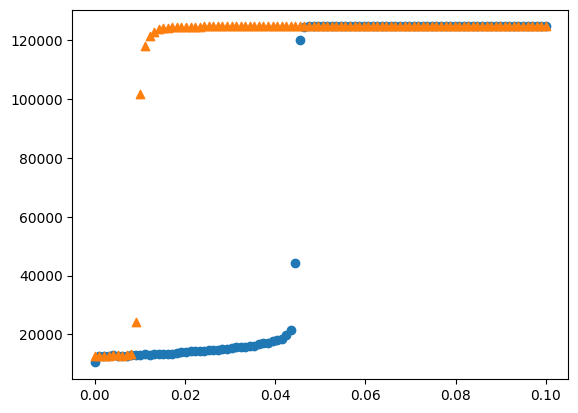

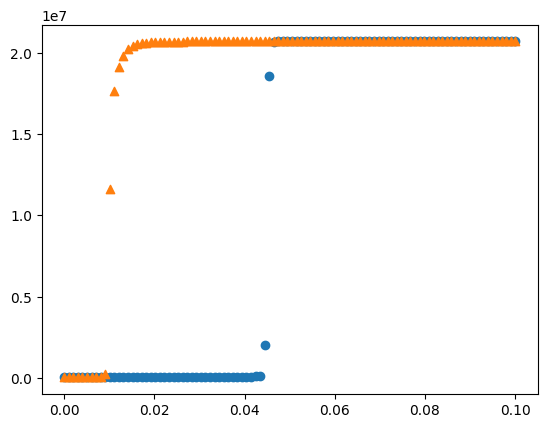

In [3]:
import time
n = 500
a=2.2
G = graphWithComplement(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 100)
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m)
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m) 
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


In [7]:
import time
import numpy as np
import networkx as nx

n = 500
a = 2.2
G = graphWithComplement(n)
m = 0
t = 0

max_its = 800000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

up_edges = []
up_tris = []
down_edges = []
down_tris = []

b_vals = np.linspace(0, 0.1, 50)
prev_avg_edges = None
prev_avg_tris = None


#upsweep
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                # revert
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            edges_sum += m
            tris_sum += t

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
            if rel_diff_edges < tol and rel_diff_tris < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")

    up_edges.append(prev_avg_edges)
    up_tris.append(prev_avg_tris)

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0
    
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                # revert
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            edges_sum += m
            tris_sum += t

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
            if rel_diff_edges < tol and rel_diff_tris < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")

    down_edges.append(prev_avg_edges)
    down_tris.append(prev_avg_tris)


b = 0.0000, iters = 550000, time = 13.41s, converged = True
b = 0.0020, iters = 200000, time = 5.58s, converged = True
b = 0.0041, iters = 150000, time = 4.23s, converged = True
b = 0.0061, iters = 150000, time = 3.80s, converged = True
b = 0.0082, iters = 250000, time = 6.50s, converged = True
b = 0.0102, iters = 250000, time = 6.40s, converged = True
b = 0.0122, iters = 50000, time = 1.49s, converged = True
b = 0.0143, iters = 250000, time = 5.73s, converged = True
b = 0.0163, iters = 50000, time = 1.40s, converged = True
b = 0.0184, iters = 200000, time = 5.21s, converged = True
b = 0.0204, iters = 50000, time = 1.67s, converged = True
b = 0.0224, iters = 100000, time = 2.88s, converged = True
b = 0.0245, iters = 200000, time = 5.57s, converged = True
b = 0.0265, iters = 150000, time = 3.99s, converged = True
b = 0.0286, iters = 50000, time = 1.70s, converged = True
b = 0.0306, iters = 200000, time = 5.84s, converged = True
b = 0.0327, iters = 200000, time = 4.74s, converged = True


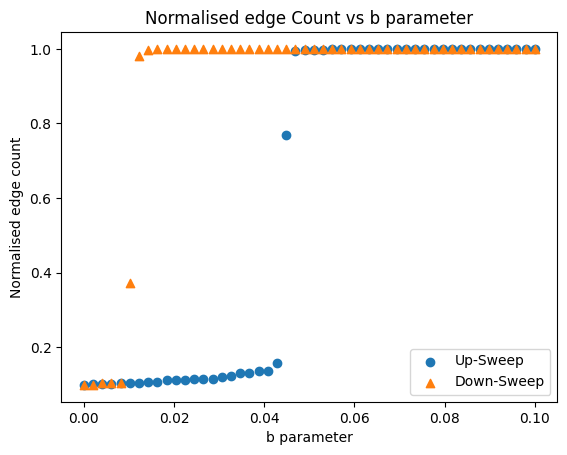

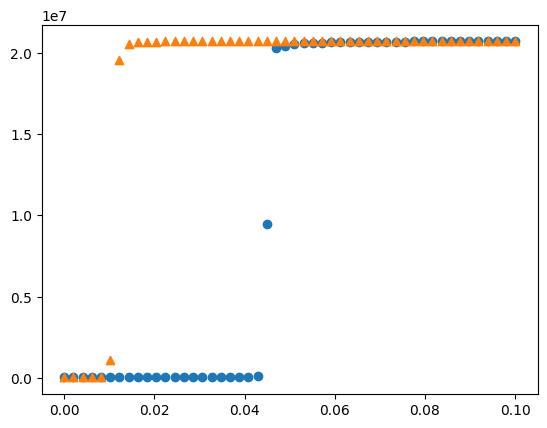

In [ ]:
import matplotlib.pyplot as plt
up_edges = np.array(up_edges)
up_edges = up_edges / (n*(n-1)/2)
down_edges = np.array(down_edges)
down_edges = down_edges / (n*(n-1)/2)


plt.show()

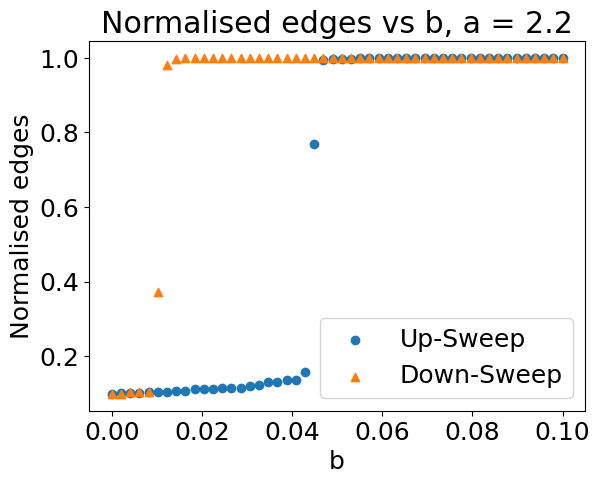

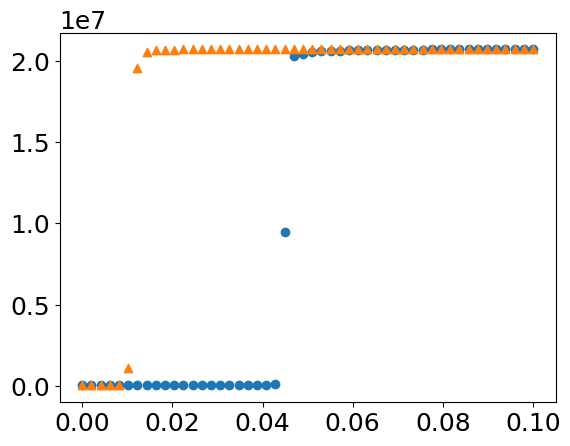

In [17]:
import matplotlib
matplotlib.rcParams.update({'font.size':18})
plt.figure()
plt.scatter(b_vals, up_edges, label='Up-Sweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'Down-Sweep', marker = '^')
plt.title('Normalised edges vs b, a = 2.2')
plt.xlabel('b')
plt.ylabel('Normalised edges')
plt.legend(loc='lower right')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

In [20]:
import time

n = 500

max_its = 1000000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

a_vals = np.linspace(0.5, 3, 50)
b_vals = np.linspace(0, 0.05, 50)

up_tri_results = []
down_tri_results = []

up_edge_results = []
down_edge_results = []

for a in a_vals:
    prev_avg_edges = None
    prev_avg_tris = None
    start_time = time.time()
    G = graphWithComplement(n)
    m = 0
    t = 0
    up_edges = []
    up_tris = []
    down_edges = []
    down_tris = []
    #upsweep
    for b in b_vals:
        total_edges = 0
        total_tris = 0

        converged = False
        iteration = 0

        while iteration < max_its and not converged:
            edges_sum = 0
            tris_sum = 0

            for _ in range(check_interval):
                i, j = np.random.randint(0, n, 2)
                while i == j:
                    i, j = np.random.randint(0, n, 2)
                if G.has_edge(i, j):
                    delta_t = -G.number_of_common_neighbors(i, j, m)
                    delta_m = -1
                    G.remove_edge(i, j)
                else:
                    delta_t = G.number_of_common_neighbors(i, j, m)
                    delta_m = 1
                    G.add_edge(i, j)

                dH = -(a * delta_m - b * delta_t)
                if np.log(np.random.uniform()) <= dH:
                    m += delta_m
                    t += delta_t
                else:
                    # revert
                    if delta_m == -1:
                        G.add_edge(i, j)
                    else:
                        G.remove_edge(i, j)

                edges_sum += m
                tris_sum += t

            iteration += check_interval

            avg_edges = edges_sum / check_interval
            avg_tris = tris_sum / check_interval

            if prev_avg_edges is not None:
                rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
                rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
                if rel_diff_edges < tol and rel_diff_tris < tol:
                    print(b,_)
                    converged = True

            prev_avg_edges = avg_edges
            prev_avg_tris = avg_tris

        up_edges.append(prev_avg_edges)
        up_tris.append(prev_avg_tris)
        print(f"a = {a:.4f}, b = {b:.4f}, iters = {iteration}")

    #downsweep
    for b in reversed(b_vals):
        total_edges = 0
        total_tris = 0
        
        converged = False
        iteration = 0

        while iteration < max_its and not converged:
            edges_sum = 0
            tris_sum = 0

            for _ in range(check_interval):
                i, j = np.random.randint(0, n, 2)
                while i == j:
                    i, j = np.random.randint(0, n, 2)
                if G.has_edge(i, j):
                    delta_t = -G.number_of_common_neighbors(i, j, m)
                    delta_m = -1
                    G.remove_edge(i, j)
                else:
                    delta_t = G.number_of_common_neighbors(i, j, m)
                    delta_m = 1
                    G.add_edge(i, j)

                dH = -(a * delta_m - b * delta_t)
                if np.log(np.random.uniform()) <= dH:
                    m += delta_m
                    t += delta_t
                else:
                    # revert
                    if delta_m == -1:
                        G.add_edge(i, j)
                    else:
                        G.remove_edge(i, j)

                edges_sum += m
                tris_sum += t

            iteration += check_interval

            avg_edges = edges_sum / check_interval
            avg_tris = tris_sum / check_interval

            if prev_avg_edges is not None:
                rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
                rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
                if rel_diff_edges < tol and rel_diff_tris < tol:
                    converged = True

            prev_avg_edges = avg_edges
            prev_avg_tris = avg_tris

        down_edges.append(prev_avg_edges)
        down_tris.append(prev_avg_tris)
        print(f"a = {a:.4f}, b = {b:.4f}, iters = {iteration}")
    up_tri_results.append(up_tris)
    down_tri_results.append(down_tris)
    up_edge_results.append(up_edges)
    down_edge_results.append(down_edges)
    print(f"a = {a:.4f}, time = {time.time() - start_time:.2f}s")



0.0 49999
a = 0.5000, b = 0.0000, iters = 550000
0.0010204081632653062 49999
a = 0.5000, b = 0.0010, iters = 250000
0.0020408163265306124 49999
a = 0.5000, b = 0.0020, iters = 400000
0.0030612244897959186 49999
a = 0.5000, b = 0.0031, iters = 350000
0.004081632653061225 49999
a = 0.5000, b = 0.0041, iters = 300000
0.005102040816326531 49999
a = 0.5000, b = 0.0051, iters = 550000
a = 0.5000, b = 0.0061, iters = 1000000
0.0071428571428571435 49999
a = 0.5000, b = 0.0071, iters = 550000
0.00816326530612245 49999
a = 0.5000, b = 0.0082, iters = 300000
0.009183673469387756 49999
a = 0.5000, b = 0.0092, iters = 200000
0.010204081632653062 49999
a = 0.5000, b = 0.0102, iters = 150000
0.011224489795918368 49999
a = 0.5000, b = 0.0112, iters = 50000
0.012244897959183675 49999
a = 0.5000, b = 0.0122, iters = 50000
0.01326530612244898 49999
a = 0.5000, b = 0.0133, iters = 50000
0.014285714285714287 49999
a = 0.5000, b = 0.0143, iters = 50000
0.015306122448979593 49999
a = 0.5000, b = 0.0153, iter

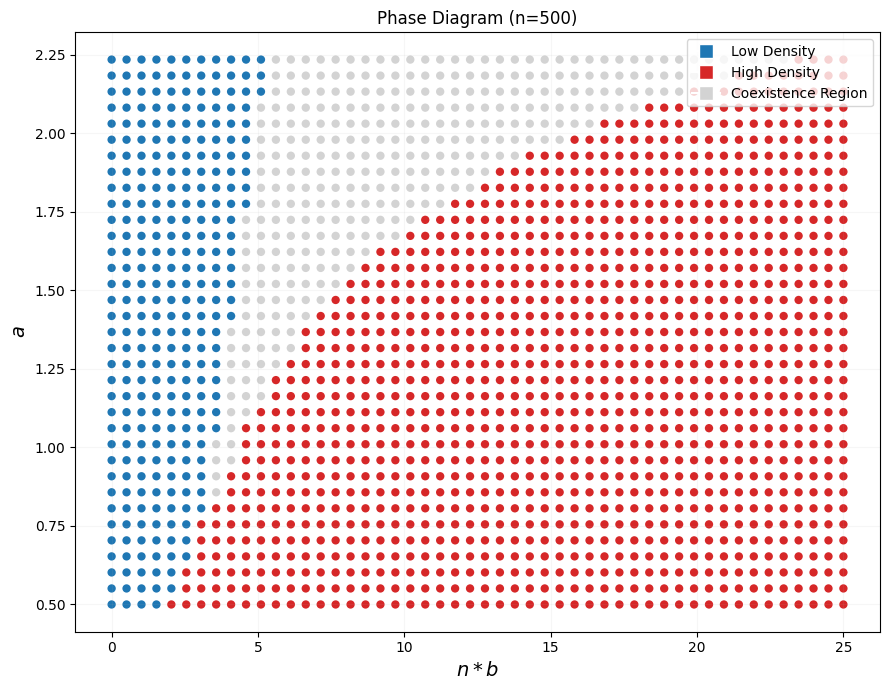

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Preparation & Parameters ---
n_nodes = n  # assuming 'n' variable from simulation is still available

# Convert results to 2D numpy arrays for easier math
E_up = np.array(up_edge_results)
# CRITICAL: Reverse the down results along axis 1 so they align with b_vals
E_down = np.array([row[::-1] for row in down_edge_results])

# Define Thresholds
max_possible_edges = n_nodes * (n_nodes - 1) / 2

# Hysteresis threshold: If difference between up and down is bigger than this%
# we call it coexistence. (Adjust 0.05 if needed, e.g., between 0.02 and 0.10)
hyst_threshold = 0.2 * max_possible_edges

# Density threshold: Midpoint to distinguish low from high when stable
density_threshold = 0.5 * max_possible_edges


# Lists to store coordinates and colors for plotting
plot_x = []
plot_y = []
plot_colors = []

# --- 2. Classification Loop ---
# Iterate through every simulated point
for i in range(len(a_vals)-15):
    for j in range(len(b_vals)):
        
        # Get coordinates for the plot
        # X-axis is n * alpha (which is n * b)
        x_coord = b_vals[j]*n
        # Y-axis is theta (which is a)
        y_coord = a_vals[i]
        
        # Get edge counts
        e_u = E_up[i, j]
        e_d = E_down[i, j]
        
        # Calculate difference (hysteresis magnitude)
        diff = e_d - e_u
        avg_e = (e_u + e_d) / 2.0

        # Determine Color based on region definition
        if diff > hyst_threshold:
            # Coexistence: Significant difference between up and down sweeps
            c = 'lightgray' 
        elif avg_e < density_threshold:
            # Stable Low Density: No significant diff, low edge count
            c = 'tab:blue'
        else:
            # Stable High Density: No significant diff, high edge count
            c = 'tab:red'
            
        plot_x.append(x_coord)
        plot_y.append(y_coord)
        plot_colors.append(c)


# --- 3. Plotting ---
plt.figure(figsize=(9, 7))

# Scatter plot with defined colors
# s=50 controls point size, marker='s' uses squares which pack nicely
plt.scatter(plot_x, plot_y, c=plot_colors, edgecolors='none')

# Formatting to match the reference image style
plt.xlabel(r'$n*b$', fontsize=14)
plt.ylabel(r'$a$', fontsize=14)
plt.title(f"Phase Diagram (n={n_nodes})")

# Create a custom legend (since scatter handles individual points)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Low Density',
           markerfacecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='High Density',
           markerfacecolor='tab:red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Coexistence Region',
           markerfacecolor='lightgray', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout()
plt.show()

In [25]:
print(up_edge_results)
print(down_edge_results)
print(up_tri_results)
print(down_tri_results)

[[47100.64346, 49098.83148, 52643.19754, 56451.32412, 62036.54102, 74360.37934, 102069.9148, 114713.43676, 118949.27436, 121224.0174, 122554.46648, 122884.15952, 123257.43498, 123625.73912, 123911.65178, 124158.56726, 124319.3592, 124450.22542, 124536.3128, 124594.52266, 124643.02644, 124675.86468, 124701.20342, 124718.76778, 124730.06898, 124735.65974, 124742.45684, 124746.1542, 124747.99494, 124749.44256, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0], [45487.41204, 46941.26116, 50255.2873, 53764.46754, 59653.34184, 68999.72796, 96785.03726, 113721.46902, 118802.51222, 121137.03484, 122433.44912, 122796.47048, 123190.69468, 123541.12422, 123842.71782, 124094.16458, 124269.91556, 124404.1441, 124505.15066, 124570.73786, 124627.24352, 124664.98072, 124687.33244, 124700.00324, 124710.4342, 124721.87846, 124731.68934, 124739.9687, 124741

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

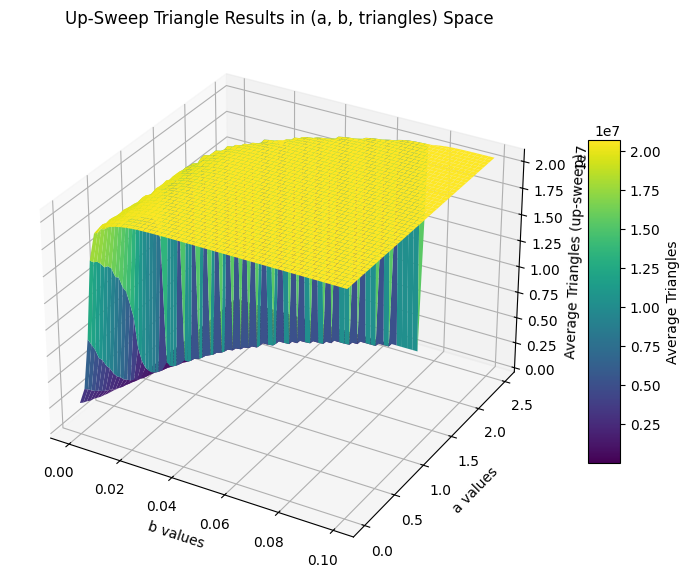

In [5]:
# Convert results list to array
np_up_tri_results = np.array(up_tri_results)  # shape: (len(a_vals), len(b_vals))

# Create meshgrid for a and b
A, B = np.meshgrid(b_vals, a_vals)  # note order (b_vals first) to match dimensions

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, B, np_up_tri_results, cmap='viridis', edgecolor='none')

# Labels and title
ax.set_xlabel('b values')
ax.set_ylabel('a values')
ax.set_zlabel('Average Triangles (up-sweep)')
ax.set_title('Up-Sweep Triangle Results in (a, b, triangles) Space')

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Average Triangles')
plt.show()

In [6]:
%matplotlib widget


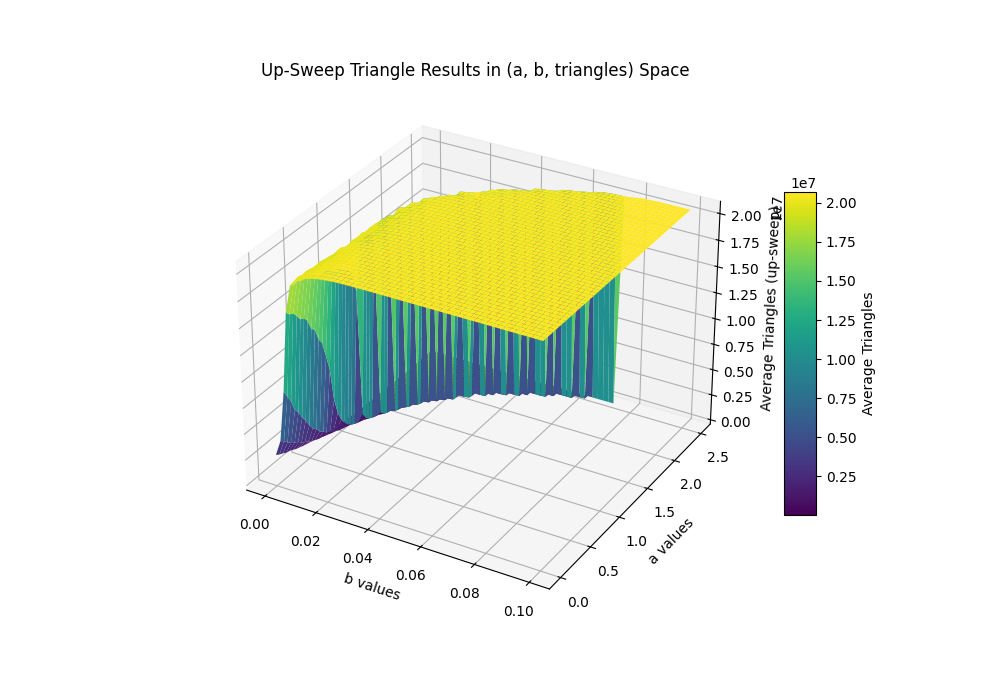

In [7]:
# Convert results list to array
np_up_tri_results = np.array(up_tri_results)  # shape: (len(a_vals), len(b_vals))

# Create meshgrid for a and b
A, B = np.meshgrid(b_vals, a_vals)  # note order (b_vals first) to match dimensions

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, B, np_up_tri_results, cmap='viridis', edgecolor='none')

# Labels and title
ax.set_xlabel('b values')
ax.set_ylabel('a values')
ax.set_zlabel('Average Triangles (up-sweep)')
ax.set_title('Up-Sweep Triangle Results in (a, b, triangles) Space')

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Average Triangles')
plt.show()